In [1]:
!pip install --no-index --find-links /kaggle/input/datasets/hinlphmhng/uav-seg-offline-assets/offline_assets/packages segmentation-models-pytorch albumentations omegaconf torchmetrics

Looking in links: /kaggle/input/datasets/hinlphmhng/uav-seg-offline-assets/offline_assets/packages
Processing /kaggle/input/datasets/hinlphmhng/uav-seg-offline-assets/offline_assets/packages/segmentation_models_pytorch-0.5.0-py3-none-any.whl


In [2]:
import os
from pathlib import Path

# 1. Thiết lập cấu hình và định nghĩa rõ các tập
INPUT_DIR = Path('/kaggle/input')

# Cấu hình chia sequence theo yêu cầu
SPLIT_CONFIG = {
    'train': ['seq1', 'seq3', 'seq4', 'seq5', 'seq8', 'seq9'],
    'val': ['seq2'],
    'test': ['seq6', 'seq7']
}

print("=== BẮT ĐẦU TÌM VÀ CHIA DATASET THEO SEQUENCE ===")

# Các list chứa đường dẫn ảnh cho từng tập
train_files = []
val_files = []
test_files = []

# 2. Duyệt qua thư mục và phân loại ảnh vào các tập tương ứng
found_sequences = set()

for dataset in INPUT_DIR.iterdir():
    if not dataset.is_dir(): continue
    
    # Tìm tất cả các thư mục có tên bắt đầu bằng 'seq' (hoặc chứa 'color')
    for seq_dir in dataset.rglob('*'):
        if seq_dir.is_dir() and (seq_dir / 'color').exists():
            seq_name = seq_dir.name
            found_sequences.add(seq_name)
            
            # Thu thập toàn bộ ảnh trong thư mục color của sequence này
            color_dir = seq_dir / 'color'
            images = list(color_dir.glob('*.png')) + list(color_dir.glob('*.jpg'))
            
            # Phân loại vào đúng list dựa trên tên sequence
            if seq_name in SPLIT_CONFIG['train']:
                train_files.extend(images)
            elif seq_name in SPLIT_CONFIG['val']:
                val_files.extend(images)
            elif seq_name in SPLIT_CONFIG['test']:
                test_files.extend(images)
            else:
                print(f"[CẢNH BÁO] Tìm thấy thư mục '{seq_name}' nhưng không nằm trong danh sách phân chia (SPLIT_CONFIG).")

# Kiểm tra xem có thiếu sequence nào không
expected_seqs = set(SPLIT_CONFIG['train'] + SPLIT_CONFIG['val'] + SPLIT_CONFIG['test'])
missing_seqs = expected_seqs - found_sequences
if missing_seqs:
    print(f"\n[LỖI CẢNH BÁO] Không tìm thấy các sequences sau trong /kaggle/input: {missing_seqs}")
    print("Vui lòng kiểm tra lại tên thư mục (có thể bị sai chữ hoa/thường, ví dụ 'Seq1' thay vì 'seq1').\n")

# Thêm chốt chặn lỗi:
total_images = len(train_files) + len(val_files) + len(test_files)
if total_images == 0:
    raise ValueError("Không tìm thấy ảnh nào! Hãy kiểm tra lại định dạng file hoặc cấu trúc thư mục.")

# 3. Hàm hỗ trợ để lấy danh sách mask tương ứng (Dùng khi training)
def get_mask_paths(image_paths):
    mask_paths = []
    for p in image_paths:
        # 1. Thử thay 'color' bằng 'label' hoặc 'labels' (các tên phổ biến)
        # và thử các đuôi file phổ biến (.png, .jpg)
        possible_mask_dirs = ['label', 'labels', 'semantic', 'masks']
        found = False
        
        for mask_dir_name in possible_mask_dirs:
            # Tạo đường dẫn thử nghiệm
            temp_path = Path(str(p).replace('/color/', f'/{mask_dir_name}/'))
            
            # Kiểm tra các đuôi file có thể có
            for ext in ['.png', '.jpg', '.jpeg']:
                test_path = temp_path.with_suffix(ext)
                if test_path.exists():
                    mask_paths.append(test_path)
                    found = True
                    break
            if found: break
            
        if not found:
            # Nếu vẫn không thấy, in ra để debug chính xác thư mục đó có gì
            parent_dir = p.parent.parent
            print(f"[CẢNH BÁO] Không tìm thấy mask cho: {p.name}")
            print(f"Thư mục sequence chứa các folder: {[d.name for d in parent_dir.iterdir() if d.is_dir()]}")
            mask_paths.append(None) # Đánh dấu lỗi
            
    return mask_paths

train_masks = get_mask_paths(train_files)
val_masks = get_mask_paths(val_files)
test_masks = get_mask_paths(test_files)

# 4. Hiển thị kết quả
print("-" * 50)
print(f"📊 KẾT QUẢ CHIA THEO SEQUENCE CỤ THỂ:")
print(f"✅ Tập TRAIN (seq1,3,4,5,8,9): {len(train_files)} ảnh")
print(f"✅ Tập VALID (seq2)          : {len(val_files)} ảnh")
print(f"✅ Tập TEST  (seq6,7)        : {len(test_files)} ảnh")
print(f"Tổng số ảnh thu thập được    : {total_images} ảnh")
print("-" * 50)

# Ví dụ kiểm tra file
if len(train_files) > 0:
    print(f"Ví dụ 1 file TRAIN: {train_files[0]}")
    print(f"Ví dụ mask TRAIN  : {train_masks[0]}")

=== BẮT ĐẦU TÌM VÀ CHIA DATASET THEO SEQUENCE ===
[CẢNH BÁO] Tìm thấy thư mục 'seq15' nhưng không nằm trong danh sách phân chia (SPLIT_CONFIG).
[CẢNH BÁO] Tìm thấy thư mục 'seq17' nhưng không nằm trong danh sách phân chia (SPLIT_CONFIG).
[CẢNH BÁO] Tìm thấy thư mục 'seq14' nhưng không nằm trong danh sách phân chia (SPLIT_CONFIG).
[CẢNH BÁO] Tìm thấy thư mục 'seq18' nhưng không nằm trong danh sách phân chia (SPLIT_CONFIG).
[CẢNH BÁO] Tìm thấy thư mục 'seq16' nhưng không nằm trong danh sách phân chia (SPLIT_CONFIG).
[CẢNH BÁO] Tìm thấy thư mục 'seq13' nhưng không nằm trong danh sách phân chia (SPLIT_CONFIG).
[CẢNH BÁO] Tìm thấy thư mục 'seq11' nhưng không nằm trong danh sách phân chia (SPLIT_CONFIG).
[CẢNH BÁO] Tìm thấy thư mục 'seq10' nhưng không nằm trong danh sách phân chia (SPLIT_CONFIG).
[CẢNH BÁO] Tìm thấy thư mục 'seq12' nhưng không nằm trong danh sách phân chia (SPLIT_CONFIG).
--------------------------------------------------
📊 KẾT QUẢ CHIA THEO SEQUENCE CỤ THỂ:
✅ Tập TRAIN (seq

In [3]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from pathlib import Path

LABEL_COLORS = [
    (0, 255, 255),    # 0: Sky
    (0, 127, 0),      # 1: Deciduous_trees
    (19, 132, 69),    # 2: Coniferous_trees
    (0, 53, 65),      # 3: Fallen_trees
    (130, 76, 0),     # 4: Dirt_ground
    (152, 251, 152),  # 5: Ground_vegetation
    (151, 126, 171),  # 6: Rocks
    (250, 150, 0),    # 7: Building
    (115, 176, 195),  # 8: Fence
    (123, 123, 123),  # 9: Car
    (0, 0, 0),        # 10: Empty
]
CLASS_NAMES = [
    'Sky', 'Deciduous_trees', 'Coniferous_trees', 'Fallen_trees',
    'Dirt_ground', 'Ground_vegetation', 'Rocks', 'Building',
    'Fence', 'Car', 'Empty',
]
NUM_CLASSES = len(CLASS_NAMES)  # = 11
PALETTE = np.array(LABEL_COLORS, dtype=np.uint8)

RGB_TO_CLASS_LUT = np.full((256, 256, 256), NUM_CLASSES - 1, dtype=np.uint8)
for cid, color in enumerate(LABEL_COLORS):
    RGB_TO_CLASS_LUT[color[0], color[1], color[2]] = cid

def fast_rgb_to_mask(rgb_arr):
    return RGB_TO_CLASS_LUT[rgb_arr[..., 0], rgb_arr[..., 1], rgb_arr[..., 2]]

def class_id_to_rgb_fast(class_map):
    return PALETTE[class_map]

In [5]:
import os
import random
import multiprocessing
import numpy as np
import torch

def seed_everything(seed=2025):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Đổi seed ở đây mỗi lần chạy: 42 / 123 / 2025
SEED = 2025
seed_everything(SEED)

MODEL_NAME      = 'unetpp'
ENCODER         = 'resnet50'
ENCODER_WEIGHTS = 'imagenet'
IMG_SIZE        = (1024, 1024)
BATCH_SIZE      = 4
EPOCHS          = 100
LR              = 1e-4
NUM_WORKERS     = 4
PATIENCE        = 15
SAVE_TOP_K      = 2
USE_AMP         = True

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"[INFO] Device: {DEVICE}")
if DEVICE == 'cuda':
    print(f"[INFO] GPU: {torch.cuda.get_device_name()}")

[INFO] Device: cuda
[INFO] GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition


In [6]:
import os
from pathlib import Path

IS_KAGGLE  = os.path.exists('/kaggle')
OUTPUT_DIR = Path('/kaggle/working/outputs') if IS_KAGGLE else Path('outputs')
CKPT_DIR   = OUTPUT_DIR / 'checkpoints'
CKPT_DIR.mkdir(parents=True, exist_ok=True)

def upload_to_drive(path):
    pass

In [7]:
import torch

class CheckpointSaver:
    def __init__(self, dirpath, top_k=3, maximize=True):
        self.dirpath  = dirpath
        self.top_k    = top_k
        self.maximize = maximize
        self.saved_ckpts = []  # list of (score, filepath)

    def save_if_best(self, state_dict, epoch, current_score):
        filename = f"epoch_{epoch:03d}_miou_{current_score:.4f}.pth"
        filepath = os.path.join(self.dirpath, filename)

        self.saved_ckpts.append((current_score, filepath))
        self.saved_ckpts.sort(key=lambda x: x[0], reverse=self.maximize)

        top_k_paths = [ckpt[1] for ckpt in self.saved_ckpts[:self.top_k]]

        if filepath in top_k_paths:
            torch.save(state_dict, filepath)
            print(f'  * [TOP {self.top_k}] mIoU: {current_score:.4f} -> {filename}')
            upload_to_drive(filepath)

            # Xóa checkpoint ngoài top-k
            while len(self.saved_ckpts) > self.top_k:
                _, removed = self.saved_ckpts.pop()  # xóa phần tử tệ nhất
                if os.path.exists(removed):
                    os.remove(removed)
            return True
        else:
            # Không lọt top-k, chưa lưu file nên chỉ cần xóa khỏi list
            self.saved_ckpts = [c for c in self.saved_ckpts if c[1] != filepath]
            return False

In [8]:
import os
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
from PIL import Image
import albumentations as A
from albumentations.pytorch import ToTensorV2

INPUT_DIR = Path('/kaggle/input')
SPLIT_CONFIG = {
    'train': ['seq1', 'seq3', 'seq4', 'seq5', 'seq8', 'seq9'],
    'val':   ['seq2'],
    'test':  ['seq6', 'seq7']
}

def collect_data():
    data = {'train': [], 'val': [], 'test': []}
    for dataset_path in INPUT_DIR.iterdir():
        if not dataset_path.is_dir(): continue
        for color_dir in dataset_path.rglob('color'):
            seq_dir  = color_dir.parent
            seq_name = seq_dir.name
            # Tìm folder mask
            mask_dir = seq_dir / 'label'
            if not mask_dir.exists():
                mask_dir = seq_dir / 'labels'
            if not mask_dir.exists(): continue
            # Xác định tập
            target_set = None
            for key, seq_list in SPLIT_CONFIG.items():
                if seq_name in seq_list:
                    target_set = key
                    break
            if not target_set: continue
            # Ghép cặp ảnh - mask
            for img_p in sorted(list(color_dir.glob('*.png')) + list(color_dir.glob('*.jpg'))):
                mask_p = (mask_dir / img_p.name).with_suffix('.png')
                if not mask_p.exists():
                    mask_p = (mask_dir / img_p.name).with_suffix('.jpg')
                if mask_p.exists():
                    data[target_set].append((str(img_p), str(mask_p)))
    return data['train'], data['val'], data['test']

train_files, val_files, test_files = collect_data()
print(f"[INFO] Train: {len(train_files)} | Val: {len(val_files)} | Test: {len(test_files)}")

if len(train_files) == 0:
    raise ValueError("Không tìm thấy dữ liệu! Kiểm tra lại cấu trúc thư mục.")

class ForestDataset(Dataset):
    def __init__(self, file_list, transform=None):
        self.file_list = file_list
        self.transform = transform

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        img_path, mask_path = self.file_list[idx]
        img      = np.array(Image.open(img_path).convert('RGB'))
        mask_rgb = np.array(Image.open(mask_path).convert('RGB'))
        mask     = fast_rgb_to_mask(mask_rgb)
        if self.transform:
            aug  = self.transform(image=img, mask=mask)
            img, mask = aug['image'], aug['mask']
        return img, mask.long()

train_tf = A.Compose([
    A.Resize(*IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ShiftScaleRotate(scale_limit=0.1, rotate_limit=15, p=0.3, border_mode=0),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.3),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])
val_tf = A.Compose([
    A.Resize(*IMG_SIZE),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

train_ds = ForestDataset(train_files, train_tf)
val_ds   = ForestDataset(val_files,   val_tf)

def worker_init_fn(worker_id):
    np.random.seed(SEED + worker_id)
    random.seed(SEED + worker_id)

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=True, drop_last=True,
    worker_init_fn=worker_init_fn,
    generator=torch.Generator().manual_seed(SEED),
)

val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=NUM_WORKERS, pin_memory=True)
print(f'[OK] Dataloaders ready. Train: {len(train_loader)} batches | Val: {len(val_loader)} batches')

/usr/local/lib/python3.12/dist-packages/albumentations/check_version.py:147: UserWarning: Error fetching version info <urlopen error [Errno -3] Temporary failure in name resolution>
  data = fetch_version_info()


[INFO] Train: 8677 | Val: 1501 | Test: 2873
[OK] Dataloaders ready. Train: 2169 batches | Val: 376 batches


/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [9]:
import shutil, glob
import torch.nn as nn
import segmentation_models_pytorch as smp

print("=== CHUẨN BỊ TRỌNG SỐ OFFLINE ===")
CACHE_DIR = '/root/.cache/torch/hub/checkpoints/'
os.makedirs(CACHE_DIR, exist_ok=True)

# ✅ Sửa path Kaggle dataset
WEIGHT_DIR = '/kaggle/input/datasets/itmeagain77/resnet50-pytorch-weights'
pth_files  = glob.glob(os.path.join(WEIGHT_DIR, '*.pth'))
if pth_files:
    cache_file = os.path.join(CACHE_DIR, 'resnet50-19c8e357.pth')
    if not os.path.exists(cache_file):
        shutil.copy(pth_files[0], cache_file)
        print(f"[OK] Đã copy: {os.path.basename(pth_files[0])} -> Cache")
    else:
        print("[OK] Trọng số đã có trong cache.")
else:
    print("[CẢNH BÁO] Không tìm thấy .pth offline, sẽ tải từ Internet.")

MODELS = {
    'unet':          lambda: smp.Unet(encoder_name=ENCODER, encoder_weights='imagenet', in_channels=3, classes=NUM_CLASSES),
    'unetpp':        lambda: smp.UnetPlusPlus(encoder_name=ENCODER, encoder_weights='imagenet', in_channels=3, classes=NUM_CLASSES),
    'deeplabv3plus': lambda: smp.DeepLabV3Plus(encoder_name=ENCODER, encoder_weights='imagenet', in_channels=3, classes=NUM_CLASSES),
    'segformer':     lambda: smp.Segformer(encoder_name=ENCODER, encoder_weights='imagenet', in_channels=3, classes=NUM_CLASSES),  # ✅
}

if MODEL_NAME not in MODELS:
    raise ValueError(f"MODEL_NAME '{MODEL_NAME}' không hợp lệ. Chọn trong: {list(MODELS.keys())}")

model = MODELS[MODEL_NAME]().to(DEVICE)
print(f'🚀 MODEL: {MODEL_NAME} | Encoder: {ENCODER} | Classes: {NUM_CLASSES}')
print(f'📊 Params: {sum(p.numel() for p in model.parameters()):,}')

=== CHUẨN BỊ TRỌNG SỐ OFFLINE ===
[OK] Đã copy: resnet50-19c8e357.pth -> Cache


'[Errno -3] Temporary failure in name resolution' thrown while requesting HEAD https://huggingface.co/smp-hub/resnet50.imagenet/resolve/00cb74e366966d59cd9a35af57e618af9f88efe9/config.json
Retrying in 1s [Retry 1/5].
/usr/local/lib/python3.12/dist-packages/segmentation_models_pytorch/encoders/__init__.py:136: UserWarning: Error loading resnet50 `imagenet` weights from Hugging Face Hub, trying loading from original url...
  warnings.warn(message, UserWarning)


🚀 MODEL: unetpp | Encoder: resnet50 | Classes: 11
📊 Params: 48,987,195


In [10]:
from tqdm import tqdm

def compute_class_weights(file_list, num_classes, c=1.02):
    """
    Công thức từ bài báo gốc: w = 1 / ln(c + p_class)
    p_class = tỷ lệ pixel của class đó trong toàn bộ tập train
    """
    counts = np.zeros(num_classes, dtype=np.int64)
    for _, mask_path in tqdm(file_list, desc='Computing class weights'):
        mask_rgb = np.array(Image.open(mask_path).convert('RGB'))
        mask = fast_rgb_to_mask(mask_rgb)
        for cid in range(num_classes):
            counts[cid] += (mask == cid).sum()
    total = counts.sum()
    freq  = counts / total
    w     = 1.0 / np.log(c + freq)
    w     = w / w.sum() * num_classes  # normalize
    print("\n📊 Class weights:")
    for i, (name, wi, fi) in enumerate(zip(CLASS_NAMES, w, freq)):
        print(f"  {name:<22} freq={fi*100:6.3f}%  weight={wi:.4f}")
    return torch.tensor(w, dtype=torch.float32).to(DEVICE)

class_weights = compute_class_weights(train_files, NUM_CLASSES)

Computing class weights: 100%|██████████| 8677/8677 [03:14<00:00, 44.50it/s]


📊 Class weights:
  Sky                    freq=14.325%  weight=0.2375
  Deciduous_trees        freq=16.435%  weight=0.2123
  Coniferous_trees       freq=29.036%  weight=0.1329
  Fallen_trees           freq= 0.577%  weight=1.4115
  Dirt_ground            freq= 2.003%  weight=0.9150
  Ground_vegetation      freq=35.456%  weight=0.1129
  Rocks                  freq= 1.914%  weight=0.9353
  Building               freq= 0.194%  weight=1.6549
  Fence                  freq= 0.013%  weight=1.8018
  Car                    freq= 0.047%  weight=1.7724
  Empty                  freq= 0.000%  weight=1.8135


In [11]:
# Vấn đề cũ: loss = focal + dice + 0.5 * ce  (trọng số cố định)
# Cải tiến:  loss = w_focal*focal + w_dice*dice + w_ce*ce
#            trong đó w_focal, w_dice, w_ce được học tự động qua uncertainty weighting
#            (Kendall et al., 2018) — mỗi weight là log(sigma^2), sigma được tối ưu
#            cùng với model parameters
#
# Ý tưởng: nếu một thành phần loss đang "khó" (variance cao), model sẽ tự giảm
# trọng số của nó để không bị dominated; nếu một loss đang học tốt, trọng số tăng.

class AdaptiveFocalDiceLoss(nn.Module):
    """
    Kết hợp Focal Loss + Dice Loss + Weighted CE với trọng số thích nghi.

    Sử dụng Multi-Task Uncertainty Weighting (Kendall et al., 2018):
        L_total = sum_i [ (1/2*sigma_i^2) * L_i + log(sigma_i) ]

    log_sigma_i là tham số learnable — được tối ưu cùng model.
    Điều này tốt hơn fixed weighting vì:
    - Không cần tune thủ công tỷ lệ giữa các loss
    - Tự điều chỉnh theo từng batch/epoch dựa trên độ khó
    - Có thể quan sát quá trình các sigma thay đổi để hiểu behavior của model
    """
    def __init__(self, class_weights=None):
        super().__init__()

        # 3 thành phần loss
        self.focal = smp.losses.FocalLoss(
            mode=smp.losses.MULTICLASS_MODE, gamma=2.0)
        self.dice  = smp.losses.DiceLoss(
            mode=smp.losses.MULTICLASS_MODE,
            from_logits=True,
            classes=list(range(NUM_CLASSES - 1)))  # bỏ class Empty
        self.ce    = nn.CrossEntropyLoss(
            weight=class_weights,
            ignore_index=NUM_CLASSES - 1)

        # log(sigma^2) learnable — khởi tạo = 0 nghĩa là sigma=1, weight=0.5
        # Dùng log để đảm bảo sigma > 0 trong suốt quá trình train
        self.log_sigma_focal = nn.Parameter(torch.zeros(1))
        self.log_sigma_dice  = nn.Parameter(torch.zeros(1))
        self.log_sigma_ce    = nn.Parameter(torch.zeros(1))

    def forward(self, logits, targets):
        l_focal = self.focal(logits, targets)
        l_dice  = self.dice(logits, targets)
        l_ce    = self.ce(logits, targets)

        # Uncertainty weighting: L_i / (2*sigma_i^2) + log(sigma_i)
        # = L_i * exp(-log_sigma^2) * 0.5 + 0.5 * log_sigma^2
        w_focal = torch.exp(-self.log_sigma_focal)
        w_dice  = torch.exp(-self.log_sigma_dice)
        w_ce    = torch.exp(-self.log_sigma_ce)

        loss = (0.5 * w_focal * l_focal + 0.5 * self.log_sigma_focal
              + 0.5 * w_dice  * l_dice  + 0.5 * self.log_sigma_dice
              + 0.5 * w_ce    * l_ce    + 0.5 * self.log_sigma_ce)

        return loss, {
            'focal':       l_focal.item(),
            'dice':        l_dice.item(),
            'ce':          l_ce.item(),
            'w_focal':     w_focal.item(),
            'w_dice':      w_dice.item(),
            'w_ce':        w_ce.item(),
        }

    def get_weights(self):
        """In ra trọng số hiện tại để theo dõi quá trình thích nghi."""
        return {
            'w_focal': torch.exp(-self.log_sigma_focal).item(),
            'w_dice':  torch.exp(-self.log_sigma_dice).item(),
            'w_ce':    torch.exp(-self.log_sigma_ce).item(),
        }


criterion = AdaptiveFocalDiceLoss(class_weights=class_weights).to(DEVICE)

# Quan trọng: thêm parameters của loss vào optimizer
# để log_sigma được cập nhật cùng với model weights
optimizer = torch.optim.AdamW(
    list(model.parameters()) + list(criterion.parameters()),
    lr=LR, weight_decay=1e-2
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=EPOCHS, eta_min=1e-6)
scaler    = torch.amp.GradScaler('cuda', enabled=USE_AMP)

print("✅ AdaptiveFocalDiceLoss + Optimizer + Scheduler khởi tạo thành công!")
print(f"   Learnable loss weights: log_sigma_focal, log_sigma_dice, log_sigma_ce")
print(f"   Initial weights: {criterion.get_weights()}")

✅ AdaptiveFocalDiceLoss + Optimizer + Scheduler khởi tạo thành công!
   Learnable loss weights: log_sigma_focal, log_sigma_dice, log_sigma_ce
   Initial weights: {'w_focal': 1.0, 'w_dice': 1.0, 'w_ce': 1.0}


In [18]:
import time, gc, csv

def get_miou(cm, n_ignore_last=1):
    inter = np.diag(cm)
    union = cm.sum(1) + cm.sum(0) - inter
    iou   = np.where(union > 0, inter / union, 0.0)
    valid_iou   = iou[:-n_ignore_last]
    valid_union = union[:-n_ignore_last]
    miou = valid_iou[valid_union > 0].mean() if any(valid_union > 0) else 0.0
    return miou, iou

best_val_miou = -float('inf')
no_improve    = 0
saver         = CheckpointSaver(dirpath=CKPT_DIR, top_k=SAVE_TOP_K, maximize=True)

# Header CSV: thêm các cột w_focal, w_dice, w_ce để theo dõi adaptive weights
LOG_FILE = OUTPUT_DIR / 'training_log.csv'
with open(LOG_FILE, 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow([
        'epoch', 'train_loss', 'val_loss', 'miou',
        'w_focal', 'w_dice', 'w_ce',          # adaptive weights
        'l_focal', 'l_dice', 'l_ce',          # individual loss values
        *CLASS_NAMES[:-1]
    ])

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()

    # ── TRAIN ──────────────────────────────────────────────
    model.train()
    criterion.train()
    train_loss = 0.0
    n_train    = 0
    # Tích lũy loss components để log trung bình mỗi epoch
    loss_components_sum = {'focal': 0, 'dice': 0, 'ce': 0,
                           'w_focal': 0, 'w_dice': 0, 'w_ce': 0}

    pbar_train = tqdm(train_loader, desc=f'E{epoch} [TRAIN]')
    for imgs, masks in pbar_train:
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
        optimizer.zero_grad()

        with torch.amp.autocast('cuda', enabled=USE_AMP):
            out              = model(imgs)
            loss, components = criterion(out, masks)  # trả về tuple

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item()
        n_train    += 1
        for k in loss_components_sum:
            loss_components_sum[k] += components[k]

        pbar_train.set_postfix({
            'loss':    f'{loss.item():.4f}',
            'wF':      f'{components["w_focal"]:.2f}',
            'wD':      f'{components["w_dice"]:.2f}',
            'wCE':     f'{components["w_ce"]:.2f}',
        })

    # ── VAL ────────────────────────────────────────────────
    model.eval()
    criterion.eval()
    val_loss = 0.0
    n_val    = 0
    cm = np.zeros((NUM_CLASSES, NUM_CLASSES), dtype=np.int64)

    pbar_val = tqdm(val_loader, desc=f'E{epoch} [VAL]')
    with torch.no_grad():
        for imgs, masks in pbar_val:
            imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
            with torch.amp.autocast('cuda', enabled=USE_AMP):
                out              = model(imgs)
                loss, _          = criterion(out, masks)
                val_loss        += loss.item()
                n_val           += 1
            preds = out.argmax(1)
            p = preds.detach().cpu().numpy().flatten()
            t = masks.detach().cpu().numpy().flatten()
            valid = (t >= 0) & (t < NUM_CLASSES)
            cm += np.bincount(
                t[valid] * NUM_CLASSES + p[valid],
                minlength=NUM_CLASSES ** 2
            ).reshape(NUM_CLASSES, NUM_CLASSES)

    # ── METRICS ────────────────────────────────────────────
    avg_train = train_loss / n_train
    avg_val   = val_loss   / n_val
    miou, class_ious = get_miou(cm)
    avg_components = {k: v / n_train for k, v in loss_components_sum.items()}
    scheduler.step()

    print(f'\n▶ Epoch {epoch:03d} | Train: {avg_train:.4f} | Val: {avg_val:.4f} | mIoU: {miou:.4f} | {time.time()-t0:.0f}s')
    print(f'   Adaptive weights → Focal: {avg_components["w_focal"]:.3f} | '
          f'Dice: {avg_components["w_dice"]:.3f} | CE: {avg_components["w_ce"]:.3f}')

    # Ghi log (thêm adaptive weights)
    with open(LOG_FILE, 'a', newline='') as f:
        writer = csv.writer(f)
        writer.writerow([
            epoch, avg_train, avg_val, miou,
            avg_components['w_focal'], avg_components['w_dice'], avg_components['w_ce'],
            avg_components['focal'],   avg_components['dice'],   avg_components['ce'],
            *[f'{class_ious[i]:.4f}' for i in range(NUM_CLASSES - 1)]
        ])

    # ── SAVE & EARLY STOPPING ──────────────────────────────
    checkpoint_dict = {
        'epoch':                epoch,
        'model_state_dict':     model.state_dict(),
        'criterion_state_dict': criterion.state_dict(),  # lưu cả adaptive weights
        'optimizer_state_dict': optimizer.state_dict(),
        'miou':                 miou,
        'loss_weights':         criterion.get_weights(),
        'scheduler_state_dict': scheduler.state_dict(),
        'scaler_state_dict':    scaler.state_dict(),
        'random_states': {
            'python':   random.getstate(),
            'numpy':    np.random.get_state(),
            'torch':    torch.get_rng_state(),
            'cuda':     torch.cuda.get_rng_state_all(),
        },
    }
    is_best = saver.save_if_best(state_dict=checkpoint_dict, epoch=epoch, current_score=miou)

    if is_best:
        best_val_miou = miou
        no_improve    = 0
        print(f"  ⭐ New best! Class-wise IoU:")
        for i, name in enumerate(CLASS_NAMES[:-1]):
            print(f"    - {name:<22}: {class_ious[i]:.4f}")
    else:
        no_improve += 1

    del cm
    gc.collect()
    torch.cuda.empty_cache()

    if no_improve >= PATIENCE:
        print(f'🛑 Early Stopping at Epoch {epoch}')
        break

print(f'\n✅ Training done! Best val mIoU: {best_val_miou:.4f}')
print(f'   Final adaptive weights: {criterion.get_weights()}')

E1 [VAL]: 100%|██████████| 376/376 [00:55<00:00,  6.77it/s]



▶ Epoch 001 | Train: 0.5742 | Val: 0.1141 | mIoU: 0.5565 | 695s
   Adaptive weights → Focal: 1.119 | Dice: 1.128 | CE: 1.082
  * [TOP 2] mIoU: 0.5565 -> epoch_001_miou_0.5565.pth
  ⭐ New best! Class-wise IoU:
    - Sky                   : 0.0000
    - Deciduous_trees       : 0.7392
    - Coniferous_trees      : 0.7757
    - Fallen_trees          : 0.4772
    - Dirt_ground           : 0.8309
    - Ground_vegetation     : 0.8527
    - Rocks                 : 0.7855
    - Building              : 0.8108
    - Fence                 : 0.0000
    - Car                   : 0.2932


E2 [VAL]: 100%|██████████| 376/376 [00:54<00:00,  6.90it/s]
/tmp/ipykernel_231/4192849017.py:6: RuntimeWarning: invalid value encountered in divide
  iou   = np.where(union > 0, inter / union, 0.0)



▶ Epoch 002 | Train: 0.0900 | Val: -0.1061 | mIoU: 0.6012 | 692s
   Adaptive weights → Focal: 1.402 | Dice: 1.413 | CE: 1.347
  * [TOP 2] mIoU: 0.6012 -> epoch_002_miou_0.6012.pth
  ⭐ New best! Class-wise IoU:
    - Sky                   : 0.0000
    - Deciduous_trees       : 0.7300
    - Coniferous_trees      : 0.7741
    - Fallen_trees          : 0.5000
    - Dirt_ground           : 0.7983
    - Ground_vegetation     : 0.8471
    - Rocks                 : 0.7575
    - Building              : 0.8605
    - Fence                 : 0.0000
    - Car                   : 0.7450


E3 [VAL]: 100%|██████████| 376/376 [00:54<00:00,  6.90it/s]


...


▶ Epoch 057 | Train: -1.3481 | Val: -1.3200 | mIoU: 0.7520 | 690s
   Adaptive weights → Focal: 9.138 | Dice: 6.120 | CE: 5.171
  * [TOP 2] mIoU: 0.7520 -> epoch_057_miou_0.7520.pth
  ⭐ New best! Class-wise IoU:
    - Sky                   : 0.0000
    - Deciduous_trees       : 0.7882
    - Coniferous_trees      : 0.8132
    - Fallen_trees          : 0.7290
    - Dirt_ground           : 0.8513
    - Ground_vegetation     : 0.8860
    - Rocks                 : 0.8697
    - Building              : 0.9303
    - Fence                 : 0.7676
    - Car                   : 0.8847


E58 [VAL]: 100%|██████████| 376/376 [00:54<00:00,  6.86it/s]



▶ Epoch 058 | Train: -1.3503 | Val: -1.3206 | mIoU: 0.7464 | 691s
   Adaptive weights → Focal: 9.153 | Dice: 6.136 | CE: 5.183


E59 [TRAIN]:  40%|████      | 875/2169 [04:16<06:19,  3.41it/s, loss=-1.5437, wF=9.17, wD=6.16, wCE=5.19]


KeyboardInterrupt: 

In [19]:
# ════════════════════════════════════════════════════════
# CELL RESUME
# tiếp tục train từ checkpoint đã lưu
# ════════════════════════════════════════════════════════
import time, gc, csv, random
import numpy as np
import torch

def get_miou(cm, n_ignore_last=1):
    inter = np.diag(cm)
    union = cm.sum(1) + cm.sum(0) - inter
    iou   = np.where(union > 0, inter / union, 0.0)
    valid_iou   = iou[:-n_ignore_last]
    valid_union = union[:-n_ignore_last]
    miou = valid_iou[valid_union > 0].mean() if any(valid_union > 0) else 0.0
    return miou, iou

# ── CẤU HÌNH RESUME 
RESUME_CKPT   = '/kaggle/input/datasets/phmnguynkimquyn/checkpoint-e25-unetpp-addaptive123/epoch_025_miou_0.7402.pth'
START_EPOCH   = 26   # ← epoch tiếp theo sau checkpoint
RESUME_EPOCHS = 74  # ← tổng epochs muốn chạy thêm

seed_everything(SEED) 

# ── LOAD CHECKPOINT
print(f"🔄 Loading checkpoint: {RESUME_CKPT}")
ckpt = torch.load(RESUME_CKPT, map_location=DEVICE, weights_only=False)

model.load_state_dict(ckpt['model_state_dict'])
print(f"   [+] Model loaded. Epoch: {ckpt['epoch']} | mIoU: {ckpt['miou']:.4f}")

criterion.load_state_dict(ckpt['criterion_state_dict'])
print(f"   [+] Criterion (adaptive weights) restored")

optimizer.load_state_dict(ckpt['optimizer_state_dict'])
print(f"   [+] Optimizer restored")

if 'scheduler_state_dict' in ckpt:
    scheduler.load_state_dict(ckpt['scheduler_state_dict'])
    print(f"   [+] Scheduler restored. Last LR: {scheduler.get_last_lr()}")
else:
    print("   [!] Không có scheduler state — LR sẽ không đúng cosine curve")

if 'scaler_state_dict' in ckpt:
    scaler.load_state_dict(ckpt['scaler_state_dict'])
    print(f"   [+] GradScaler restored")
else:
    print("   [!] Không có scaler state — GradScaler khởi động lại")

if 'random_states' in ckpt:
    rs = ckpt['random_states']
    random.setstate(rs['python'])
    np.random.set_state(rs['numpy'])
    rng_state = rs['torch']
    if isinstance(rng_state, torch.Tensor):
        rng_state = rng_state.cpu()
    torch.set_rng_state(rng_state)
    
    cuda_states = rs['cuda']
    cuda_states = [s.cpu() if isinstance(s, torch.Tensor) else torch.ByteTensor(s).cpu() 
                   for s in cuda_states]
    torch.cuda.set_rng_state_all(cuda_states)
    print(f"   [+] Random states restored — training deterministic từ đây")
else:
    print("   [!] Không có random states — kết quả có thể khác lần trước")

# ── RESUME TRAINING LOOP ────────────────────────────────
best_val_miou = ckpt['miou']
no_improve    = 0
saver         = CheckpointSaver(dirpath=CKPT_DIR, top_k=SAVE_TOP_K, maximize=True)

LOG_FILE = OUTPUT_DIR / 'training_log_resume.csv'
with open(LOG_FILE, 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow([
        'epoch', 'train_loss', 'val_loss', 'miou',
        'w_focal', 'w_dice', 'w_ce',
        'l_focal', 'l_dice', 'l_ce',
        *CLASS_NAMES[:-1]
    ])

print(f"\n🚀 Resuming from epoch {START_EPOCH} | Best mIoU threshold: {best_val_miou:.4f}\n")

for epoch in range(START_EPOCH, START_EPOCH + RESUME_EPOCHS):
    t0 = time.time()

    # ── TRAIN ──────────────────────────────────────────────
    model.train()
    criterion.train()
    train_loss = 0.0
    n_train    = 0
    loss_components_sum = {'focal': 0, 'dice': 0, 'ce': 0,
                           'w_focal': 0, 'w_dice': 0, 'w_ce': 0}

    pbar_train = tqdm(train_loader, desc=f'E{epoch} [TRAIN]')
    for imgs, masks in pbar_train:
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
        optimizer.zero_grad()
        with torch.amp.autocast('cuda', enabled=USE_AMP):
            out              = model(imgs)
            loss, components = criterion(out, masks)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        train_loss += loss.item()
        n_train    += 1
        for k in loss_components_sum:
            loss_components_sum[k] += components[k]
        pbar_train.set_postfix({
            'loss': f'{loss.item():.4f}',
            'wF':   f'{components["w_focal"]:.2f}',
            'wD':   f'{components["w_dice"]:.2f}',
            'wCE':  f'{components["w_ce"]:.2f}',
        })

    # ── VAL ────────────────────────────────────────────────
    model.eval()
    criterion.eval()
    val_loss = 0.0
    n_val    = 0
    cm = np.zeros((NUM_CLASSES, NUM_CLASSES), dtype=np.int64)

    with torch.no_grad():
        for imgs, masks in tqdm(val_loader, desc=f'E{epoch} [VAL]'):
            imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
            with torch.amp.autocast('cuda', enabled=USE_AMP):
                out       = model(imgs)
                loss, _   = criterion(out, masks)
                val_loss += loss.item()
                n_val    += 1
            preds = out.argmax(1)
            p = preds.detach().cpu().numpy().flatten()
            t = masks.detach().cpu().numpy().flatten()
            valid = (t >= 0) & (t < NUM_CLASSES)
            cm += np.bincount(
                t[valid] * NUM_CLASSES + p[valid],
                minlength=NUM_CLASSES ** 2
            ).reshape(NUM_CLASSES, NUM_CLASSES)

    # ── METRICS ────────────────────────────────────────────
    avg_train = train_loss / n_train
    avg_val   = val_loss   / n_val
    miou, class_ious = get_miou(cm)
    avg_components = {k: v / n_train for k, v in loss_components_sum.items()}
    scheduler.step()

    print(f'\n▶ Epoch {epoch:03d} | Train: {avg_train:.4f} | Val: {avg_val:.4f} | mIoU: {miou:.4f} | {time.time()-t0:.0f}s')
    print(f'   Weights → Focal: {avg_components["w_focal"]:.3f} | '
          f'Dice: {avg_components["w_dice"]:.3f} | CE: {avg_components["w_ce"]:.3f}')

    with open(LOG_FILE, 'a', newline='') as f:
        writer = csv.writer(f)
        writer.writerow([
            epoch, avg_train, avg_val, miou,
            avg_components['w_focal'], avg_components['w_dice'], avg_components['w_ce'],
            avg_components['focal'],   avg_components['dice'],   avg_components['ce'],
            *[f'{class_ious[i]:.4f}' for i in range(NUM_CLASSES - 1)]
        ])

    # ── SAVE & EARLY STOPPING ──────────────────────────────
    checkpoint_dict = {
        'epoch':                epoch,
        'model_state_dict':     model.state_dict(),
        'criterion_state_dict': criterion.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'miou':                 miou,
        'loss_weights':         criterion.get_weights(),
        'scheduler_state_dict': scheduler.state_dict(),
        'scaler_state_dict':    scaler.state_dict(),
        'random_states': {
            'python': random.getstate(),
            'numpy':  np.random.get_state(),
            'torch':  torch.get_rng_state(),
            'cuda':   torch.cuda.get_rng_state_all(),
        },
    }
    is_best = saver.save_if_best(state_dict=checkpoint_dict, epoch=epoch, current_score=miou)

    if is_best:
        best_val_miou = miou
        no_improve    = 0
        print(f"  ⭐ New best! Class-wise IoU:")
        for i, name in enumerate(CLASS_NAMES[:-1]):
            print(f"    - {name:<22}: {class_ious[i]:.4f}")
    else:
        no_improve += 1

    del cm
    gc.collect()
    torch.cuda.empty_cache()

    if no_improve >= PATIENCE:
        print(f'🛑 Early Stopping at Epoch {epoch}')
        break

print(f'\n✅ Resume done! Best val mIoU: {best_val_miou:.4f}')

🔄 Loading checkpoint: /kaggle/input/datasets/phmnguynkimquyn/checkpoint-e25-unetpp-addaptive123/epoch_025_miou_0.7402.pth


FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/input/datasets/phmnguynkimquyn/checkpoint-e25-unetpp-addaptive123/epoch_025_miou_0.7402.pth'

In [25]:
import shutil
from IPython.display import FileLink

checkpoint_folder = '/kaggle/working/outputs/checkpoints'
output_zip_name   = '/kaggle/working/my_forest_checkpoints'

if os.path.exists(checkpoint_folder):
    shutil.make_archive(output_zip_name, 'zip', checkpoint_folder)
    print(f"✅ Archived: {output_zip_name}.zip")
    display(FileLink('my_forest_checkpoints.zip'))
else:
    print(f"❌ Folder not found: {checkpoint_folder}")

✅ Archived: /kaggle/working/my_forest_checkpoints.zip


/kaggle/working/my_forest_checkpoints.zip

In [12]:
import torch
import numpy as np
from tqdm import tqdm
from PIL import Image
import matplotlib.pyplot as plt

def get_miou(cm, n_ignore_last=1):
    """Tính mIoU, bỏ qua n class cuối (mặc định bỏ class Empty)"""
    inter = np.diag(cm)
    union = cm.sum(1) + cm.sum(0) - inter
    iou   = np.where(union > 0, inter / union, 0.0)
    valid_iou   = iou[:-n_ignore_last]
    valid_union = union[:-n_ignore_last]
    miou = valid_iou[valid_union > 0].mean() if any(valid_union > 0) else 0.0
    return miou, iou

# 1. Load Checkpoint tốt nhất
BEST_CKPT = '/kaggle/input/datasets/phmnguynkimquyn/checkpoint-e97-unetpp-addaptive2025/epoch_097_miou_0.7602.pth' 

if os.path.exists(BEST_CKPT):
    print(f"🔄 Đang nạp model tốt nhất từ: {BEST_CKPT}")
    ckpt = torch.load(BEST_CKPT, map_location=DEVICE, weights_only=False)
    model.load_state_dict(ckpt['model_state_dict'])
    print(f"✅ Đã nạp thành công mIoU kỷ lục: {ckpt.get('miou', ckpt.get('metric', 0)):.4f}")
else:
    print("⚠️ Cảnh báo: Không tìm thấy file checkpoint. Đang dùng model hiện tại trong RAM.")

# 2. Khởi tạo Dataloader cho tập Test
test_ds = ForestDataset(test_files, val_tf) # Dùng val_tf (không augment)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

# 3. Vòng lặp Test
model.eval()
cm_test = np.zeros((NUM_CLASSES, NUM_CLASSES), dtype=np.int64)

print(f"🚀 Đang chạy Test trên {len(test_files)} ảnh...")
with torch.no_grad():
    for imgs, masks in tqdm(test_loader, desc='Testing'):
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
        
        with torch.amp.autocast('cuda', enabled=USE_AMP):
            out = model(imgs)
            
        preds = out.argmax(1).detach().cpu().numpy().flatten()
        targets = masks.detach().cpu().numpy().flatten()
        
        mask_valid = (targets >= 0) & (targets < NUM_CLASSES)
        cm_test += np.bincount(
            targets[mask_valid] * NUM_CLASSES + preds[mask_valid], 
            minlength=NUM_CLASSES**2
        ).reshape(NUM_CLASSES, NUM_CLASSES)

# 4. Tính toán kết quả cuối cùng
miou_test, ious_test = get_miou(cm_test)

print("\n" + "="*50)
print(f"📊 KẾT QUẢ ĐÁNH GIÁ TẬP TEST (SEQ6, SEQ7)")
print("="*50)
for i, name in enumerate(CLASS_NAMES[:-1]):
    status = f"{ious_test[i]:.4f}" if cm_test.sum(1)[i] > 0 else "N/A"
    print(f"  - {name:18s}: {status}")
print("-" * 50)
print(f"🌟 MEAN IoU (OVERALL): {miou_test:.4f}")
print("="*50)

🔄 Đang nạp model tốt nhất từ: /kaggle/input/datasets/phmnguynkimquyn/checkpoint-e97-unetpp-addaptive2025/epoch_097_miou_0.7602.pth
✅ Đã nạp thành công mIoU kỷ lục: 0.7602
🚀 Đang chạy Test trên 2873 ảnh...


Testing: 100%|██████████| 719/719 [01:48<00:00,  6.65it/s]


📊 KẾT QUẢ ĐÁNH GIÁ TẬP TEST (SEQ6, SEQ7)
  - Sky               : 0.9939
  - Deciduous_trees   : 0.7404
  - Coniferous_trees  : 0.8523
  - Fallen_trees      : 0.6921
  - Dirt_ground       : 0.8959
  - Ground_vegetation : 0.8570
  - Rocks             : 0.8782
  - Building          : 0.9252
  - Fence             : 0.6628
  - Car               : 0.8675
--------------------------------------------------
🌟 MEAN IoU (OVERALL): 0.8365



/tmp/ipykernel_163/2497485146.py:11: RuntimeWarning: invalid value encountered in divide
  iou   = np.where(union > 0, inter / union, 0.0)


Class Name      | Dice / F1  | Boundary IoU
---------------------------------------------
Sky             | 0.9760     | 0.7664
Deciduous trees | 0.8091     | 0.1881
Coniferous trees | 0.9071     | 0.2519
Fallen trees    | 0.5636     | 0.2789
Dirt ground     | 0.8711     | 0.5001
Ground vegetation | 0.8808     | 0.2853
Rocks           | 0.8928     | 0.5089
Building        | 0.8984     | 0.6853
Fence           | 0.9329     | 0.8546
Car             | 0.9033     | 0.7840
---------------------------------------------
AVERAGE (All)   | 0.8635     | 0.5104
AVERAGE (No BG) | 0.8510     | 0.4819


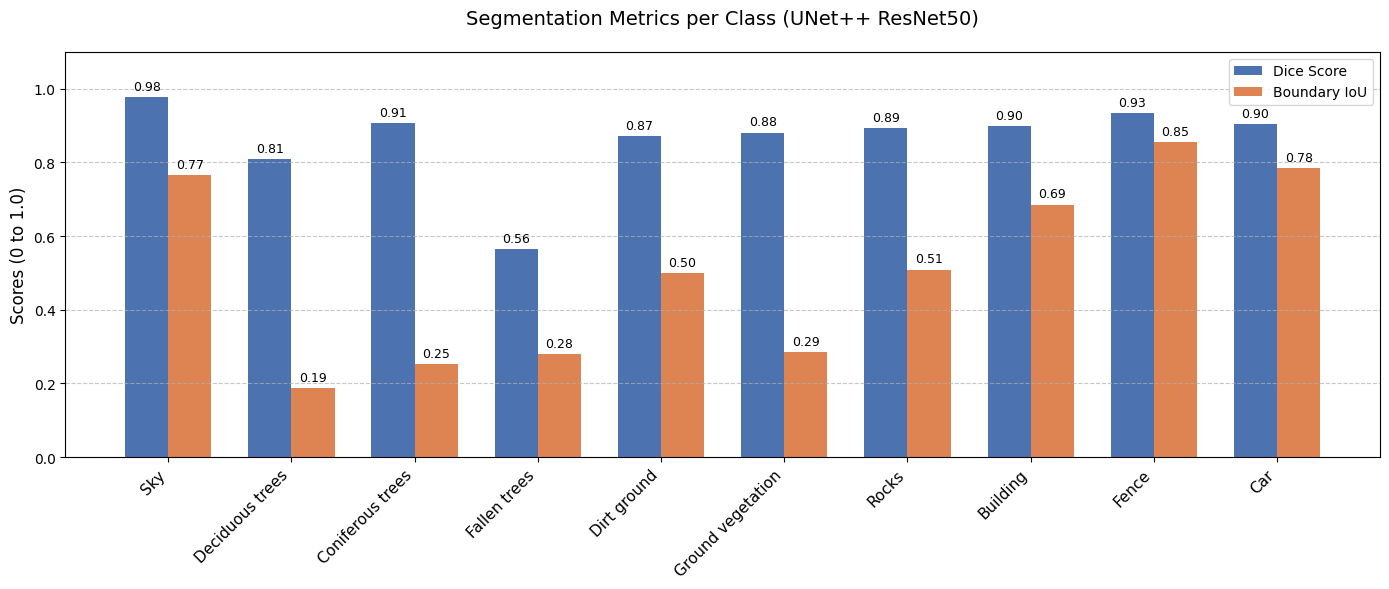

In [13]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# 1. HÀM CHUYỂN ĐỔI ONE-HOT
# ==========================================
def to_one_hot(mask, num_classes):
    """
    Chuyển đổi mask từ dạng (B, H, W) sang dạng One-hot encoding (B, C, H, W).
    """
    if mask.dim() == 4 and mask.shape[1] == 1:
        mask = mask.squeeze(1)
        
    one_hot = F.one_hot(mask.long(), num_classes=num_classes)
    return one_hot.permute(0, 3, 1, 2).float()

# ==========================================
# 2. HÀM TÍNH METRICS CHO TỪNG CLASS
# ==========================================
def calculate_metrics_multiclass_per_class(pred_logits, target, num_classes, smooth=1e-6):
    """
    Tính Dice (F1) và Boundary IoU trả về mảng điểm của từng class trong 1 batch.
    """
    pred_mask = torch.argmax(pred_logits, dim=1) # (B, H, W)
    
    pred_one_hot = to_one_hot(pred_mask, num_classes)
    target_one_hot = to_one_hot(target, num_classes)
    
    # --- TÍNH DICE SCORE ---
    inter = (pred_one_hot * target_one_hot).sum(dim=(2, 3)) 
    union = pred_one_hot.sum(dim=(2, 3)) + target_one_hot.sum(dim=(2, 3))
    dice_per_class = (2. * inter + smooth) / (union + smooth) # (B, C)
    
    # --- TÍNH BOUNDARY IOU ---
    kernel_size = 3
    pad = kernel_size // 2
    kernel = torch.ones((num_classes, 1, kernel_size, kernel_size), device=pred_logits.device)
    
    # Erosion cho prediction
    eroded_pred = F.conv2d(pred_one_hot, kernel, padding=pad, groups=num_classes)
    eroded_pred = (eroded_pred == kernel_size * kernel_size).float()
    pred_boundary = pred_one_hot - eroded_pred
    
    # Erosion cho target
    eroded_target = F.conv2d(target_one_hot, kernel, padding=pad, groups=num_classes)
    eroded_target = (eroded_target == kernel_size * kernel_size).float()
    target_boundary = target_one_hot - eroded_target
    
    # Boundary IoU
    b_inter = (pred_boundary * target_boundary).sum(dim=(2, 3))
    b_union = pred_boundary.sum(dim=(2, 3)) + target_boundary.sum(dim=(2, 3)) - b_inter
    biou_per_class = (b_inter + smooth) / (b_union + smooth)
    
    # Trả về trung bình của batch đó cho từng class -> Mảng (num_classes,)
    return dice_per_class.mean(dim=0), biou_per_class.mean(dim=0)

# ==========================================
# 3. HÀM ĐÁNH GIÁ VÀ VẼ BIỂU ĐỒ
# ==========================================
def evaluate_model_and_plot(model, dataloader, num_classes, class_names=None, device="cuda"):
    model.eval()
    
    total_dice_classes = torch.zeros(num_classes, device=device)
    total_biou_classes = torch.zeros(num_classes, device=device)
    n_batches = 0
    
    with torch.no_grad():
        for images, masks in dataloader:
            images = images.to(device)
            masks = masks.to(device)
            
            preds = model(images)
            
            # Gọi hàm trả về mảng điểm cho từng class
            batch_dice_classes, batch_biou_classes = calculate_metrics_multiclass_per_class(preds, masks, num_classes)
            
            total_dice_classes += batch_dice_classes
            total_biou_classes += batch_biou_classes
            n_batches += 1
            
    # Tính trung bình toàn bộ test set
    final_dice_classes = (total_dice_classes / n_batches).cpu().numpy()
    final_biou_classes = (total_biou_classes / n_batches).cpu().numpy()
    
    # Tự động tạo tên class nếu chưa cung cấp
    if class_names is None:
        class_names = [f"Class {i}" for i in range(num_classes)]
        
    # --- IN RA CONSOLE ---
    print(f"{'Class Name':<15} | {'Dice / F1':<10} | {'Boundary IoU':<10}")
    print("-" * 45)
    for i in range(num_classes):
        print(f"{class_names[i]:<15} | {final_dice_classes[i]:.4f}     | {final_biou_classes[i]:.4f}")
    print("-" * 45)
    print(f"{'AVERAGE (All)':<15} | {final_dice_classes.mean():.4f}     | {final_biou_classes.mean():.4f}")
    
    # Trung bình bỏ qua Background (mặc định Background là class 0)
    print(f"{'AVERAGE (No BG)':<15} | {final_dice_classes[1:].mean():.4f}     | {final_biou_classes[1:].mean():.4f}")

    # --- VẼ BIỂU ĐỒ ---
    x = np.arange(num_classes)
    width = 0.35

    fig, ax = plt.subplots(figsize=(14, 6))
    
    rects1 = ax.bar(x - width/2, final_dice_classes, width, label='Dice Score', color='#4C72B0')
    rects2 = ax.bar(x + width/2, final_biou_classes, width, label='Boundary IoU', color='#DD8452')

    ax.set_ylabel('Scores (0 to 1.0)', fontsize=12)
    ax.set_title('Segmentation Metrics per Class (UNet++ ResNet50)', fontsize=14, pad=20)
    ax.set_xticks(x)
    ax.set_xticklabels(class_names, rotation=45, ha='right', fontsize=11)
    ax.legend(loc='upper right')
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    ax.set_ylim(0, 1.1) # Dư 0.1 để số trên đầu cột không bị che

    # In giá trị lên đầu mỗi cột
    for rect in rects1 + rects2:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3), 
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.savefig('metrics_per_class.png', dpi=300, bbox_inches='tight') 
    plt.show()

# ==========================================
# 4. THỰC THI (CHẠY ĐÁNH GIÁ)
# ==========================================

my_class_names = [
    "Sky",
    "Deciduous trees",
    "Coniferous trees",
    "Fallen trees",
    "Dirt ground",
    "Ground vegetation",
    "Rocks",
    "Building",
    "Fence",
    "Car"
]

NUM_CLASSES = 10 

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

evaluate_model_and_plot(
    model=model, 
    dataloader=test_loader, 
    num_classes=NUM_CLASSES, 
    class_names=my_class_names, 
    device=device
)

In [14]:
# =====================================================
# TÍNH ĐẦY ĐỦ METRICS TỪ CONFUSION MATRIX ĐÃ CÓ
# Chạy SAU khi đã có cm_test, không cần inference lại
# =====================================================

def compute_all_metrics(cm, class_names, n_ignore_last=1):
    n = len(class_names)
    valid = slice(0, n - n_ignore_last)  # bỏ class Empty
    
    inter = np.diag(cm)
    sum_row = cm.sum(1)  # GT per class
    sum_col = cm.sum(0)  # Pred per class
    union   = sum_row + sum_col - inter
    total_pixels = cm.sum()

    # --- Per-class IoU ---
    iou = np.where(union > 0, inter / union, 0.0)
    valid_mask = union[valid] > 0
    miou = iou[valid][valid_mask].mean()

    # --- Frequency Weighted IoU (FWIoU) ---
    freq = sum_row[valid] / total_pixels  # tần suất từng class
    fwiou = (freq * iou[valid]).sum()

    # --- Pixel Accuracy ---
    pixel_acc = inter.sum() / total_pixels

    # --- Mean Pixel Accuracy (per-class accuracy rồi average) ---
    class_acc = np.where(sum_row > 0, inter / sum_row, 0.0)
    mean_pixel_acc = class_acc[valid][valid_mask].mean()

    # --- Dice / F1 per class ---
    dice = np.where((sum_row + sum_col) > 0,
                    2 * inter / (sum_row + sum_col), 0.0)
    mean_dice = dice[valid][valid_mask].mean()

    # --- In kết quả ---
    print("\n" + "="*60)
    print("📊 KẾT QUẢ ĐÁNH GIÁ ĐẦY ĐỦ - TEST SET (SEQ6, SEQ7)")
    print("="*60)
    print(f"{'Class':<22} {'IoU':>8} {'Dice/F1':>8} {'Acc':>8}")
    print("-"*60)
    for i, name in enumerate(class_names[:-1]):
        has_data = union[i] > 0
        iou_s  = f"{iou[i]:.4f}"  if has_data else "  N/A  "
        dice_s = f"{dice[i]:.4f}" if has_data else "  N/A  "
        acc_s  = f"{class_acc[i]:.4f}" if sum_row[i] > 0 else "  N/A  "
        print(f"  {name:<20} {iou_s:>8} {dice_s:>8} {acc_s:>8}")
    print("="*60)
    print(f"  {'mIoU':<20} {miou:>8.4f}")
    print(f"  {'FWIoU':<20} {fwiou:>8.4f}")
    print(f"  {'Mean Dice/F1':<20} {mean_dice:>8.4f}")
    print(f"  {'Pixel Accuracy':<20} {pixel_acc:>8.4f}")
    print(f"  {'Mean Pixel Acc':<20} {mean_pixel_acc:>8.4f}")
    print("="*60)

    return {
        'miou': miou, 'fwiou': fwiou,
        'pixel_acc': pixel_acc, 'mean_pixel_acc': mean_pixel_acc,
        'mean_dice': mean_dice,
        'iou_per_class': iou, 'dice_per_class': dice,
    }

# Gọi hàm với cm_test đã có sẵn
results = compute_all_metrics(cm_test, CLASS_NAMES)


📊 KẾT QUẢ ĐÁNH GIÁ ĐẦY ĐỦ - TEST SET (SEQ6, SEQ7)
Class                       IoU  Dice/F1      Acc
------------------------------------------------------------
  Sky                    0.9939   0.9969   0.9970
  Deciduous_trees        0.7404   0.8508   0.8663
  Coniferous_trees       0.8523   0.9202   0.9339
  Fallen_trees           0.6921   0.8181   0.8497
  Dirt_ground            0.8959   0.9451   0.9693
  Ground_vegetation      0.8570   0.9230   0.8996
  Rocks                  0.8782   0.9351   0.9505
  Building               0.9252   0.9611   0.9706
  Fence                  0.6628   0.7972   0.8527
  Car                    0.8675   0.9290   0.9321
  mIoU                   0.8365
  FWIoU                  0.8803
  Mean Dice/F1           0.9077
  Pixel Accuracy         0.9341
  Mean Pixel Acc         0.9222


/tmp/ipykernel_231/3932036886.py:17: RuntimeWarning: invalid value encountered in divide
  iou = np.where(union > 0, inter / union, 0.0)
/tmp/ipykernel_231/3932036886.py:29: RuntimeWarning: invalid value encountered in divide
  class_acc = np.where(sum_row > 0, inter / sum_row, 0.0)
/tmp/ipykernel_231/3932036886.py:34: RuntimeWarning: invalid value encountered in divide
  2 * inter / (sum_row + sum_col), 0.0)


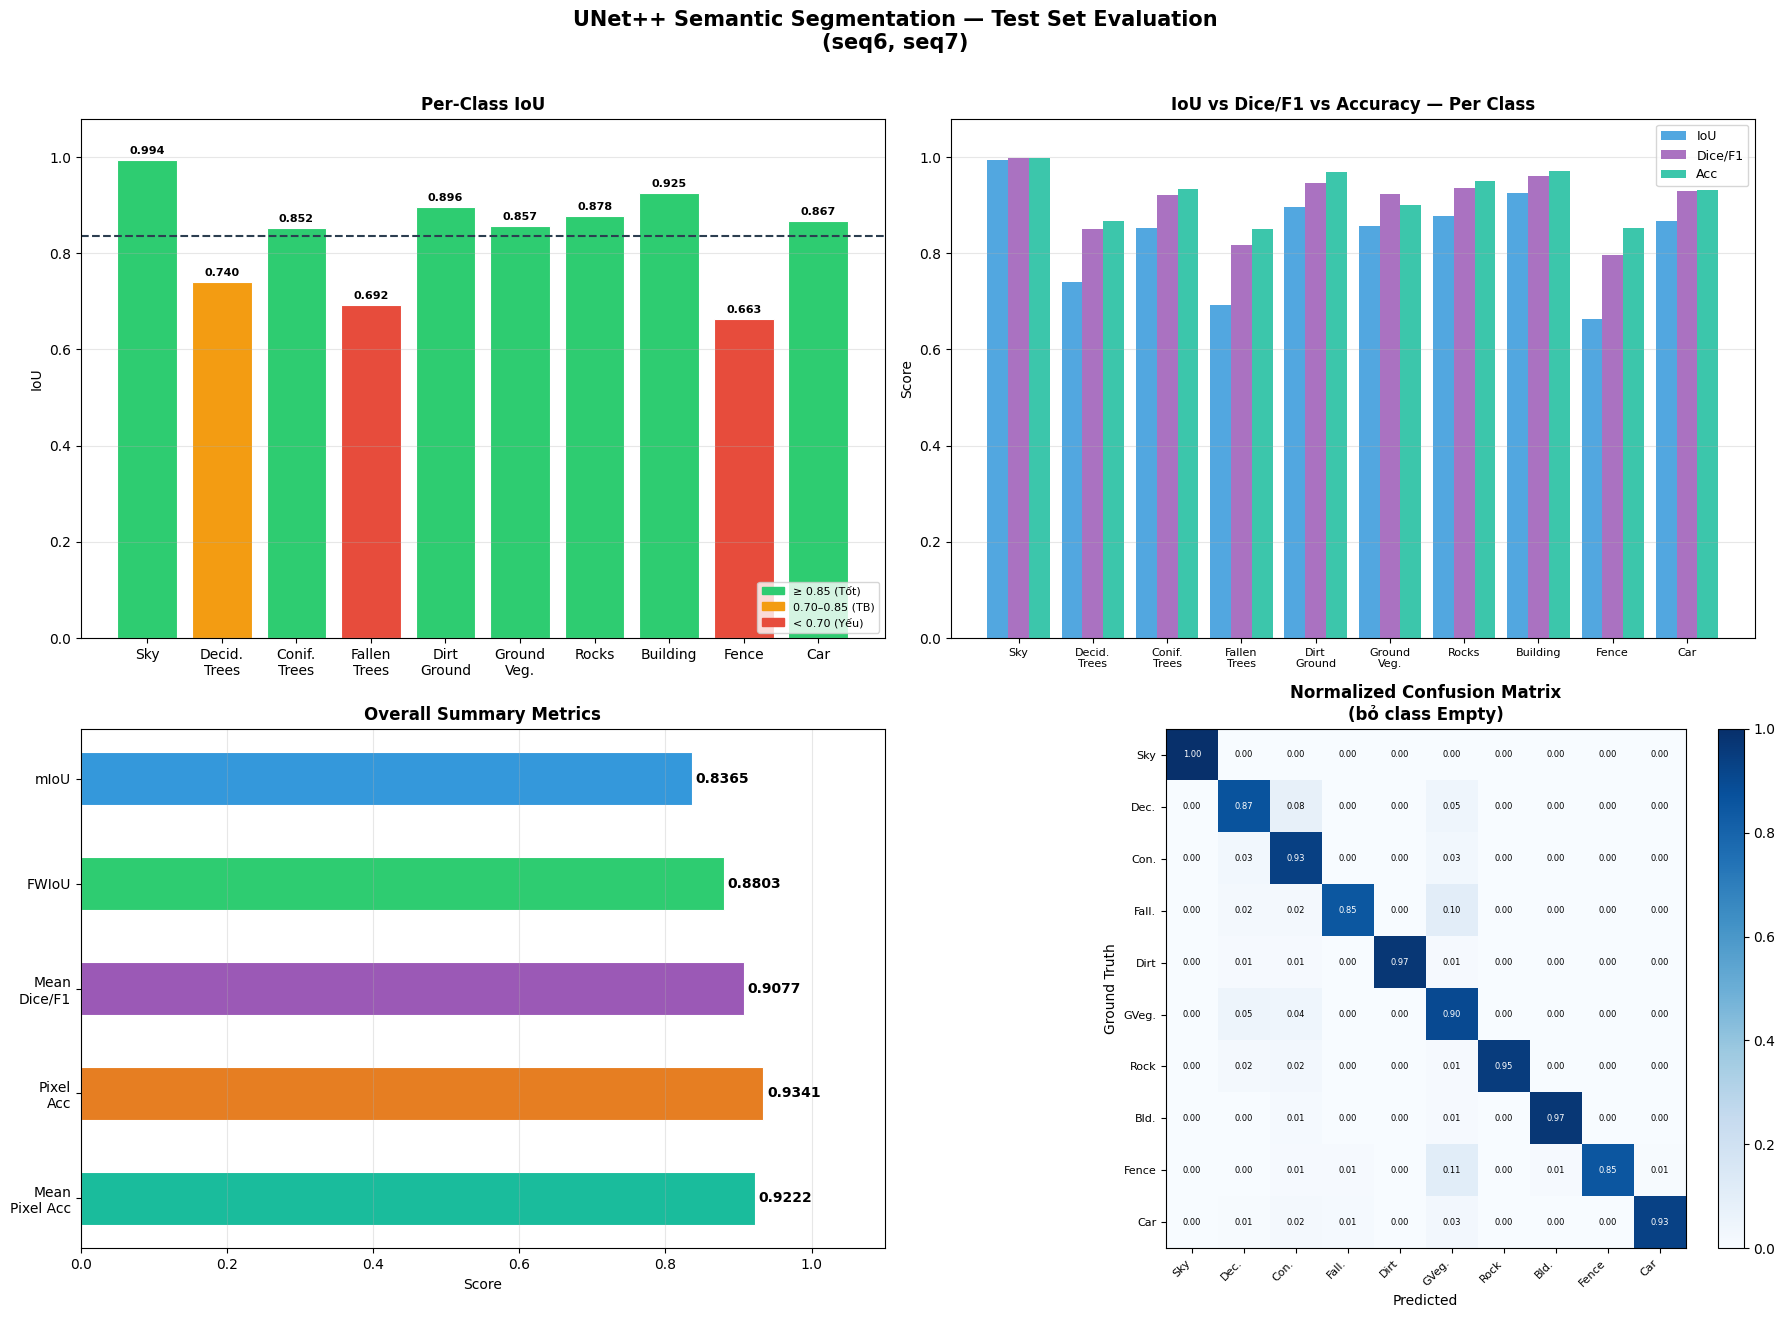

✅ Đã lưu: segmentation_evaluation.png


In [16]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Dữ liệu ──────────────────────────────────────────────
class_names_short = [
    'Sky', 'Decid.\nTrees', 'Conif.\nTrees', 'Fallen\nTrees',
    'Dirt\nGround', 'Ground\nVeg.', 'Rocks', 'Building', 'Fence', 'Car'
]
iou_vals  = results['iou_per_class'][:-1]
dice_vals = results['dice_per_class'][:-1]
acc_vals  = np.where(cm_test.sum(1)[:-1] > 0,
                     np.diag(cm_test)[:-1] / cm_test.sum(1)[:-1], 0.0)

summary_names  = ['mIoU', 'FWIoU', 'Mean\nDice/F1', 'Pixel\nAcc', 'Mean\nPixel Acc']
summary_vals   = [results['miou'], results['fwiou'],
                  results['mean_dice'], results['pixel_acc'], results['mean_pixel_acc']]

# ── Màu sắc theo IoU ─────────────────────────────────────
def iou_color(v):
    if v >= 0.85: return '#2ecc71'   # xanh lá = tốt
    if v >= 0.70: return '#f39c12'   # cam = trung bình
    return '#e74c3c'                  # đỏ = yếu

colors = [iou_color(v) for v in iou_vals]

fig, axes = plt.subplots(2, 2, figsize=(18, 13))
fig.suptitle('UNet++ Semantic Segmentation — Test Set Evaluation\n(seq6, seq7)',
             fontsize=15, fontweight='bold', y=1.01)

# ── 1. Per-class IoU ──────────────────────────────────────
ax = axes[0, 0]
bars = ax.bar(class_names_short, iou_vals, color=colors, edgecolor='white', linewidth=0.8)
ax.axhline(results['miou'], color='#2c3e50', linestyle='--', linewidth=1.5,
           label=f"mIoU = {results['miou']:.4f}")
for bar, v in zip(bars, iou_vals):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.008, f'{v:.3f}',
            ha='center', va='bottom', fontsize=8, fontweight='bold')
ax.set_ylim(0, 1.08)
ax.set_title('Per-Class IoU', fontweight='bold')
ax.set_ylabel('IoU')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
patches = [mpatches.Patch(color='#2ecc71', label='≥ 0.85 (Tốt)'),
           mpatches.Patch(color='#f39c12', label='0.70–0.85 (TB)'),
           mpatches.Patch(color='#e74c3c', label='< 0.70 (Yếu)')]
ax.legend(handles=patches, fontsize=8, loc='lower right')

# ── 2. IoU vs Dice vs Acc (grouped bar) ───────────────────
ax = axes[0, 1]
x = np.arange(len(class_names_short))
w = 0.28
ax.bar(x - w, iou_vals,  w, label='IoU',     color='#3498db', alpha=0.85)
ax.bar(x,     dice_vals, w, label='Dice/F1', color='#9b59b6', alpha=0.85)
ax.bar(x + w, acc_vals,  w, label='Acc',     color='#1abc9c', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(class_names_short, fontsize=8)
ax.set_ylim(0, 1.08)
ax.set_title('IoU vs Dice/F1 vs Accuracy — Per Class', fontweight='bold')
ax.set_ylabel('Score')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

# ── 3. Summary metrics (horizontal bar) ───────────────────
ax = axes[1, 0]
bar_colors = ['#3498db','#2ecc71','#9b59b6','#e67e22','#1abc9c']
hbars = ax.barh(summary_names, summary_vals, color=bar_colors,
                edgecolor='white', linewidth=0.8, height=0.5)
for bar, v in zip(hbars, summary_vals):
    ax.text(v + 0.005, bar.get_y() + bar.get_height()/2,
            f'{v:.4f}', va='center', fontsize=10, fontweight='bold')
ax.set_xlim(0, 1.1)
ax.set_title('Overall Summary Metrics', fontweight='bold')
ax.set_xlabel('Score')
ax.grid(axis='x', alpha=0.3)
ax.invert_yaxis()

# ── 4. Confusion matrix (normalized) ──────────────────────
ax = axes[1, 1]
cm_norm = cm_test[:-1, :-1].astype(float)
row_sum = cm_norm.sum(1, keepdims=True)
cm_norm = np.where(row_sum > 0, cm_norm / row_sum, 0.0)
short_labels = ['Sky','Dec.','Con.','Fall.','Dirt','GVeg.','Rock','Bld.','Fence','Car']
im = ax.imshow(cm_norm, cmap='Blues', vmin=0, vmax=1)
ax.set_xticks(range(10)); ax.set_xticklabels(short_labels, rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(10)); ax.set_yticklabels(short_labels, fontsize=8)
for i in range(10):
    for j in range(10):
        v = cm_norm[i, j]
        ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                fontsize=6, color='white' if v > 0.5 else 'black')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_title('Normalized Confusion Matrix\n(bỏ class Empty)', fontweight='bold')
ax.set_xlabel('Predicted'); ax.set_ylabel('Ground Truth')

plt.tight_layout()
plt.savefig('segmentation_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Đã lưu: segmentation_evaluation.png")

In [17]:
from IPython.display import FileLink

# Hiển thị link tải trực tiếp cho file ảnh
display(FileLink('segmentation_evaluation.png'))

/kaggle/working/segmentation_evaluation.png

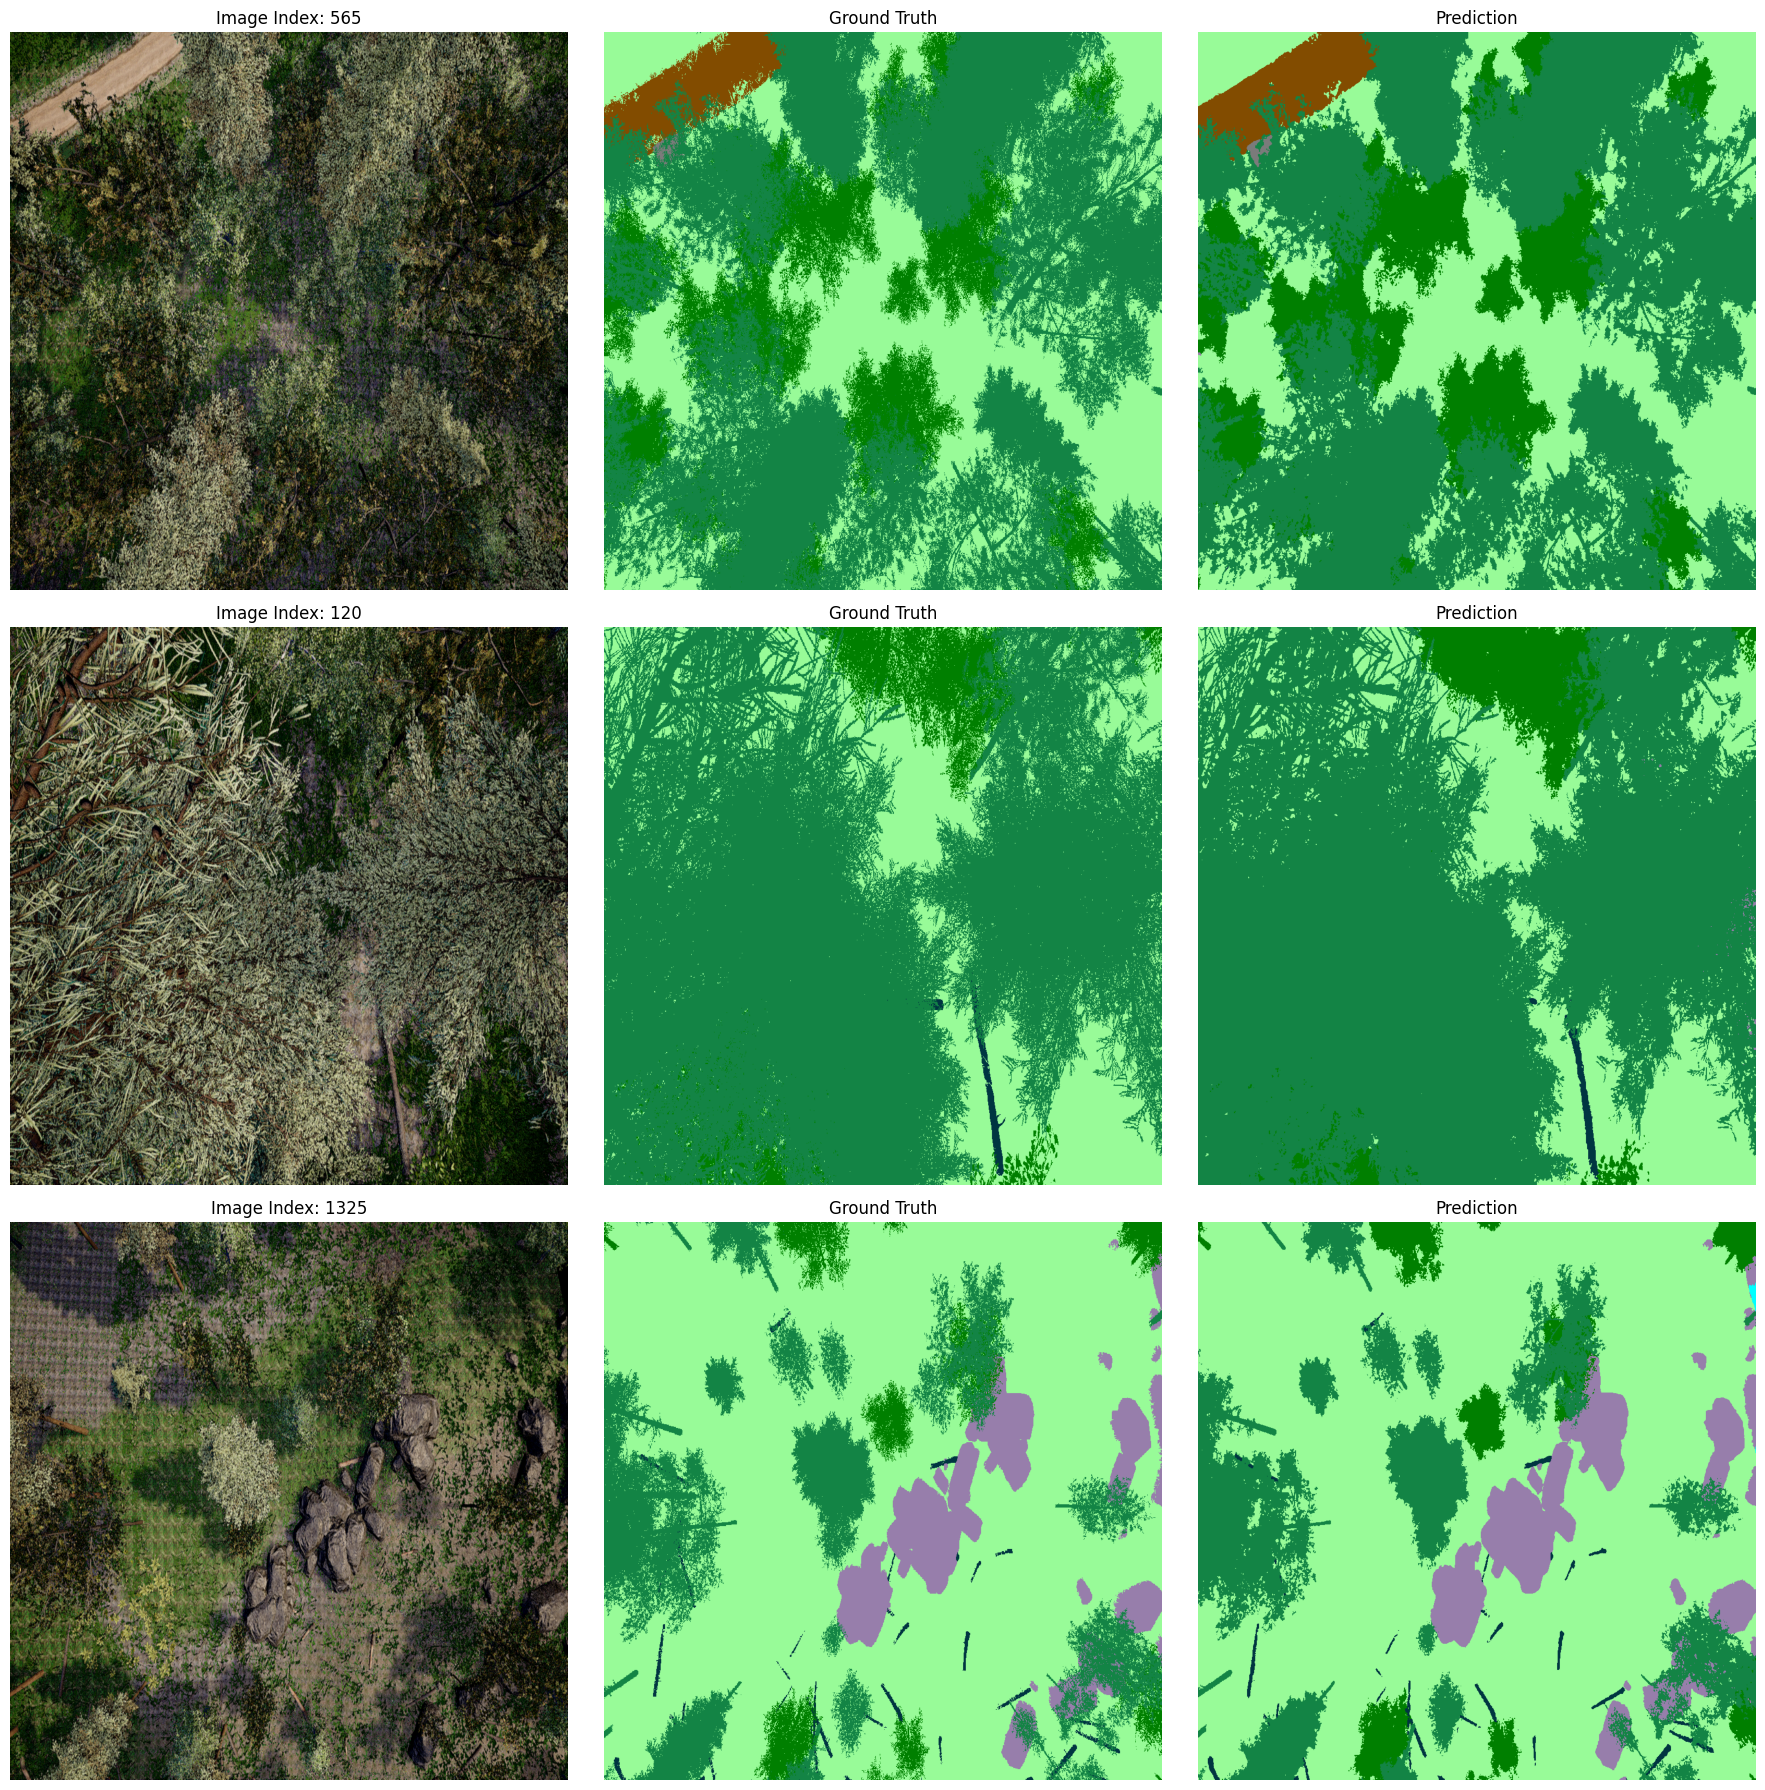

In [18]:
def visualize_predictions(dataset, model, num_samples=3):
    model.eval()
    indices = np.random.choice(len(dataset), num_samples, replace=False)
    
    plt.figure(figsize=(18, 6 * num_samples))
    
    for i, idx in enumerate(indices):
        img_tensor, mask_id = dataset[idx]
        
        # Inference
        with torch.no_grad():
            input_tensor = img_tensor.unsqueeze(0).to(DEVICE)
            out = model(input_tensor)
            pred_id = out.argmax(1).squeeze(0).cpu().numpy()
            
        # Chuyển đổi về RGB để hiển thị
        img_show = img_tensor.permute(1, 2, 0).numpy()
        # Un-normalize ảnh để hiển thị đúng màu
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img_show = std * img_show + mean
        img_show = np.clip(img_show, 0, 1)
        
        gt_rgb = class_id_to_rgb_fast(mask_id.numpy())
        pred_rgb = class_id_to_rgb_fast(pred_id)
        
        # Vẽ đồ thị
        plt.subplot(num_samples, 3, i*3 + 1)
        plt.imshow(img_show)
        plt.title(f"Image Index: {idx}")
        plt.axis('off')
        
        plt.subplot(num_samples, 3, i*3 + 2)
        plt.imshow(gt_rgb)
        plt.title("Ground Truth")
        plt.axis('off')
        
        plt.subplot(num_samples, 3, i*3 + 3)
        plt.imshow(pred_rgb)
        plt.title("Prediction")
        plt.axis('off')
        
    plt.tight_layout()
    plt.show()

# Chạy thử hiển thị 3 mẫu ngẫu nhiên từ tập Test
visualize_predictions(test_ds, model, num_samples=3)


🔍 PHÂN TÍCH LỖI CÁC OBJECT NHỎ

  [3] Fallen_trees
    GT pixels   : 13,574,815
    IoU         : 0.6921
    Recall      : 0.8497  (bỏ sót 15.0% GT pixels)
    Precision   : 0.7887
    Nhầm thành  :
      → Ground_vegetation     : 1,389,157 px (10.2%)
      → Deciduous_trees       :  307,442 px (2.3%)
      → Coniferous_trees      :  295,570 px (2.2%)

  [8] Fence
    GT pixels   :    220,214
    IoU         : 0.6628
    Recall      : 0.8527  (bỏ sót 14.7% GT pixels)
    Precision   : 0.7485
    Nhầm thành  :
      → Ground_vegetation     :   23,780 px (10.8%)
      → Building              :    2,500 px (1.1%)
      → Coniferous_trees      :    2,363 px (1.1%)

  [9] Car
    GT pixels   :  1,042,534
    IoU         : 0.8675
    Recall      : 0.9321  (bỏ sót 6.8% GT pixels)
    Precision   : 0.9260
    Nhầm thành  :
      → Ground_vegetation     :   27,233 px (2.6%)
      → Coniferous_trees      :   16,785 px (1.6%)
      → Fallen_trees          :   13,270 px (1.3%)

  [7] Building
   

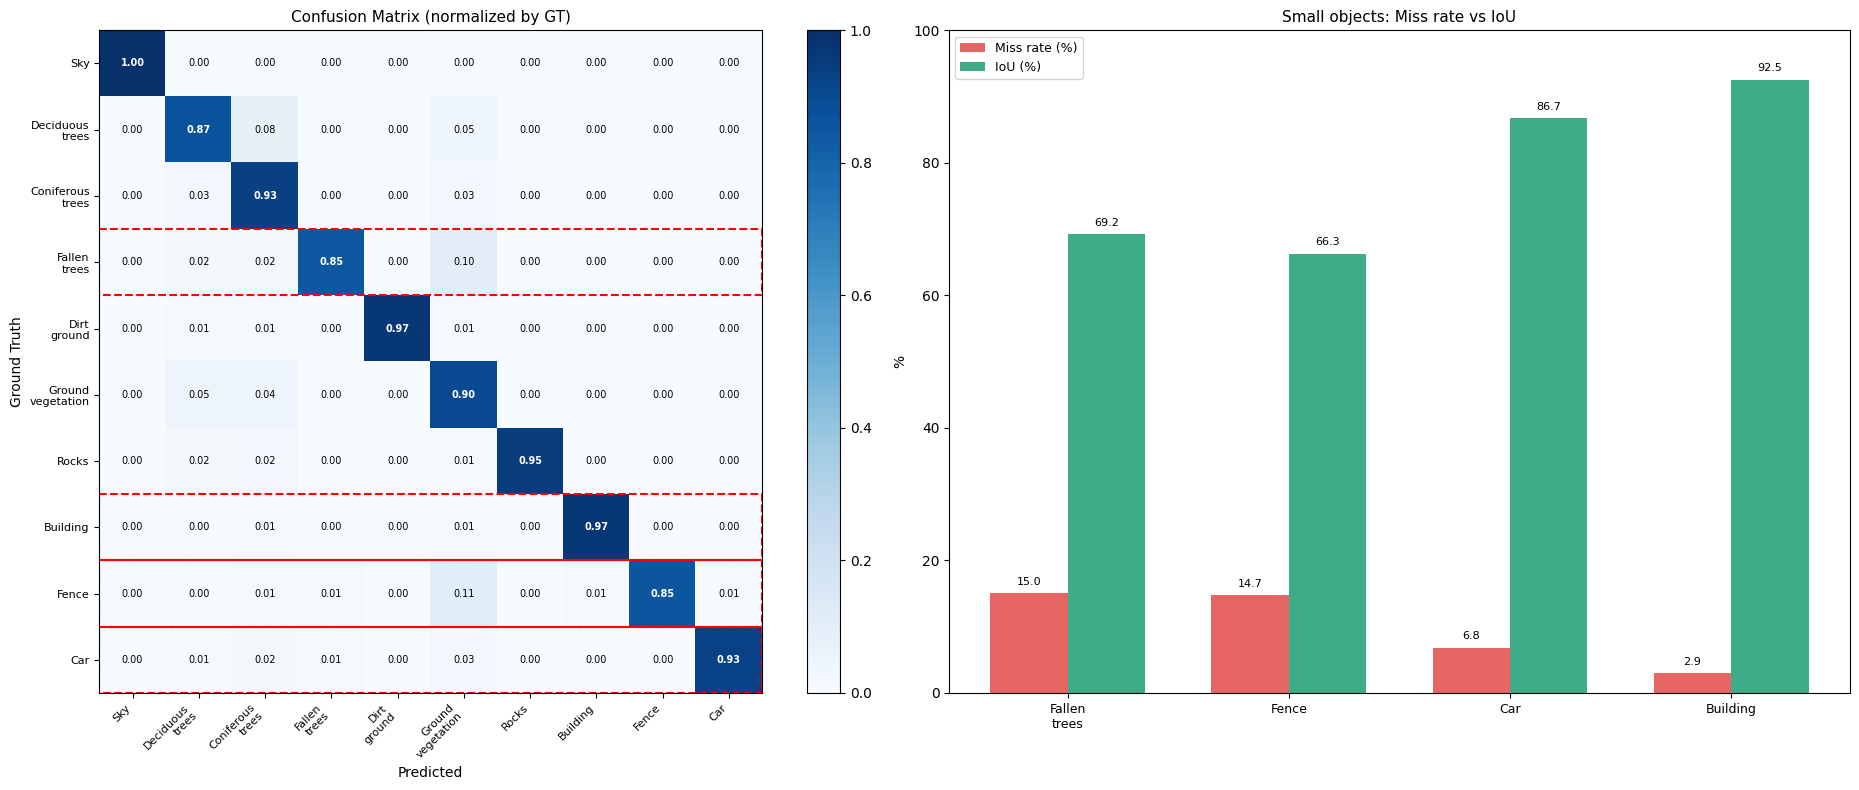

In [20]:
# Phân tích: model thường bị lỗi gì với các object nhỏ?
# Cụ thể: Fallen_trees (3), Fence (8), Car (9), Building (7)
# Các loại lỗi:
#   - Missed: GT có object nhỏ nhưng model bỏ sót hoàn toàn
#   - Confused: model nhầm object nhỏ thành class nào khác
#   - False positive: model predict có object nhỏ ở chỗ không có
SMALL_CLASSES = {
    3: 'Fallen_trees',
    8: 'Fence',
    9: 'Car',
    7: 'Building'
}


def analyze_small_object_errors(cm, class_names, small_class_ids, save_dir=None):
    """
    Phân tích lỗi chi tiết cho các class nhỏ/hiếm.
    In ra:
      1. Recall (Missed detection rate)
      2. Precision (False positive rate)  
      3. Top-3 class bị nhầm nhiều nhất
      4. Heatmap confusion matrix
    """
    n = len(class_names) - 1  # bỏ Empty

    inter     = np.diag(cm)
    row_sum   = cm.sum(axis=1)  # GT pixels per class
    col_sum   = cm.sum(axis=0)  # Predicted pixels per class

    print("\n" + "="*70)
    print("🔍 PHÂN TÍCH LỖI CÁC OBJECT NHỎ")
    print("="*70)

    error_summary = {}
    for cid in small_class_ids:
        name       = class_names[cid]
        tp         = cm[cid, cid]
        fn         = row_sum[cid] - tp          # GT có, predict sai
        fp         = col_sum[cid] - tp          # Predict có, GT không có
        total_gt   = row_sum[cid]
        recall     = tp / total_gt if total_gt > 0 else 0
        precision  = tp / (tp + fp) if (tp + fp) > 0 else 0
        iou        = tp / (tp + fp + fn) if (tp + fp + fn) > 0 else 0
        miss_rate  = fn / total_gt if total_gt > 0 else 0  # tỷ lệ bỏ sót

        # Top 3 class bị nhầm (bỏ qua chính class đó và Empty)
        confusion_row = cm[cid].copy()
        confusion_row[cid] = 0              # bỏ TP
        confusion_row[-1]  = 0              # bỏ Empty
        top3_confused = np.argsort(confusion_row)[::-1][:3]

        print(f"\n  [{cid}] {name}")
        print(f"    GT pixels   : {total_gt:>10,}")
        print(f"    IoU         : {iou:.4f}")
        print(f"    Recall      : {recall:.4f}  (bỏ sót {miss_rate*100:.1f}% GT pixels)")
        print(f"    Precision   : {precision:.4f}")
        print(f"    Nhầm thành  :")
        for j in top3_confused:
            n_confused = confusion_row[j]
            if n_confused > 0:
                pct = n_confused / total_gt * 100 if total_gt > 0 else 0
                print(f"      → {class_names[j]:<22}: {n_confused:>8,} px ({pct:.1f}%)")

        error_summary[name] = {
            'iou': iou, 'recall': recall, 'precision': precision,
            'miss_rate': miss_rate, 'total_gt_px': int(total_gt),
            'top_confusion': [(class_names[j], int(confusion_row[j]))
                              for j in top3_confused if confusion_row[j] > 0]
        }

    # ── CONFUSION MATRIX HEATMAP (normalized) ──────────────
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))

    # Plot 1: Full confusion matrix
    cm_norm = cm[:n, :n].astype(float)
    row_s   = cm_norm.sum(axis=1, keepdims=True)
    cm_norm = np.where(row_s > 0, cm_norm / row_s, 0)

    im = axes[0].imshow(cm_norm, cmap='Blues', vmin=0, vmax=1)
    axes[0].set_xticks(range(n))
    axes[0].set_yticks(range(n))
    axes[0].set_xticklabels([c.replace('_', '\n') for c in class_names[:n]],
                             fontsize=8, rotation=45, ha='right')
    axes[0].set_yticklabels([c.replace('_', '\n') for c in class_names[:n]], fontsize=8)
    axes[0].set_xlabel('Predicted', fontsize=10)
    axes[0].set_ylabel('Ground Truth', fontsize=10)
    axes[0].set_title('Confusion Matrix (normalized by GT)', fontsize=11)
    plt.colorbar(im, ax=axes[0], fraction=0.046)

    for i in range(n):
        for j in range(n):
            val = cm_norm[i, j]
            color = 'white' if val > 0.5 else 'black'
            weight = 'bold' if i == j else 'normal'
            axes[0].text(j, i, f'{val:.2f}', ha='center', va='center',
                         fontsize=7, color=color, fontweight=weight)

    # Highlight các small classes bằng khung đỏ
    for cid in small_class_ids:
        if cid < n:
            axes[0].add_patch(plt.Rectangle(
                (-0.5, cid - 0.5), n, 1,
                fill=False, edgecolor='red', linewidth=1.5, linestyle='--'))

    # Plot 2: Miss rate của small objects
    small_ids_valid = [c for c in small_class_ids if c < n]
    names_s    = [class_names[c] for c in small_ids_valid]
    miss_rates = [error_summary[class_names[c]]['miss_rate'] * 100
                  for c in small_ids_valid]
    ious_s     = [error_summary[class_names[c]]['iou'] * 100
                  for c in small_ids_valid]

    x = np.arange(len(names_s))
    w = 0.35
    bars1 = axes[1].bar(x - w/2, miss_rates, w, label='Miss rate (%)',
                        color='#E24B4A', alpha=0.85)
    bars2 = axes[1].bar(x + w/2, ious_s,    w, label='IoU (%)',
                        color='#1D9E75', alpha=0.85)

    axes[1].set_xticks(x)
    axes[1].set_xticklabels([n.replace('_', '\n') for n in names_s], fontsize=9)
    axes[1].set_ylabel('%', fontsize=10)
    axes[1].set_title('Small objects: Miss rate vs IoU', fontsize=11)
    axes[1].legend(fontsize=9)
    axes[1].set_ylim(0, 100)

    for bar in bars1:
        h = bar.get_height()
        if h > 0:
            axes[1].text(bar.get_x() + bar.get_width()/2, h + 1,
                         f'{h:.1f}', ha='center', va='bottom', fontsize=8)
    for bar in bars2:
        h = bar.get_height()
        if h > 0:
            axes[1].text(bar.get_x() + bar.get_width()/2, h + 1,
                         f'{h:.1f}', ha='center', va='bottom', fontsize=8)

    plt.tight_layout()
    if save_dir:
        path = Path(save_dir) / 'small_object_error_analysis.png'
        plt.savefig(path, dpi=150, bbox_inches='tight')
        print(f"\n💾 Saved: {path}")
    plt.show()

    return error_summary

# Chạy phân tích
small_class_ids = list(SMALL_CLASSES.keys())  # [3, 7, 8, 9]
error_summary = analyze_small_object_errors(
    cm_test, CLASS_NAMES, small_class_ids,
    save_dir=OUTPUT_DIR
)

In [21]:
import shutil
import os
from IPython.display import FileLink

# 1. Định nghĩa các đường dẫn
output_dir = '/kaggle/working/outputs'
log_dir = '/kaggle/working/outputs/logs'
# Thư mục chứa các file zip tải về
export_zip_path = '/kaggle/working/final_training_results'

# 2. Tạo một thư mục tạm để gom các file nhẹ (logs, txt, csv)
# Chúng ta sẽ không gom thư mục 'checkpoints' vì nó rất nặng và bạn đã tải rồi
temp_export_dir = '/kaggle/working/temp_results_for_report'
if os.path.exists(temp_export_dir):
    shutil.rmtree(temp_export_dir)
os.makedirs(temp_export_dir)

# Copy thư mục logs vào thư mục tạm
if os.path.exists(log_dir):
    shutil.copytree(log_dir, os.path.join(temp_export_dir, 'logs'))
    print("✅ Đã gom thư mục Logs.")

# Quét và copy các file văn bản (.txt, .csv, .json) trong thư mục output nếu có
for root, dirs, files in os.walk(output_dir):
    if 'checkpoints' in root: continue # Bỏ qua thư mục checkpoints
    for file in files:
        if file.endswith(('.txt', '.csv', '.json', '.png')):
            src_path = os.path.join(root, file)
            shutil.copy(src_path, temp_export_dir)

# 3. Nén tất cả lại thành file ZIP
shutil.make_archive(export_zip_path, 'zip', temp_export_dir)

print("-" * 50)
print(f"🎉 Đã nén xong toàn bộ kết quả báo cáo!")
print(f"📁 File: {export_zip_path}.zip")
print("-" * 50)

# 4. Hiển thị link tải
display(FileLink('final_training_results.zip'))

--------------------------------------------------
🎉 Đã nén xong toàn bộ kết quả báo cáo!
📁 File: /kaggle/working/final_training_results.zip
--------------------------------------------------


/kaggle/working/final_training_results.zip

In [13]:
import os
from pathlib import Path

# 1. Danh sách các đường dẫn dataset overcast
OVERCAST_DIRS = [
    Path('/kaggle/input/datasets/hinlphmhng/uav-forest-overcast-1'),
    Path('/kaggle/input/datasets/hinlphmhng/uav-forest-overcast-2')
]

overcast_files = []
found_sequences = []

print("=== BẮT ĐẦU GỘP DỮ LIỆU TỪ NHIỀU NGUỒN OVERCAST ===")

# 2. Duyệt qua từng dataset trong danh sách
for base_path in OVERCAST_DIRS:
    if not base_path.exists():
        print(f"⚠️ Cảnh báo: Không tìm thấy thư mục {base_path}")
        continue
        
    print(f"📂 Đang quét: {base_path.name}...")
    
    # Tìm các thư mục sequence bên trong
    for seq_dir in base_path.rglob('*'):
        if seq_dir.is_dir() and (seq_dir / 'color').exists():
            found_sequences.append(seq_dir.name)
            color_dir = seq_dir / 'color'
            
            # Lấy tất cả ảnh png/jpg trong folder color của sequence này
            images = list(color_dir.glob('*.png')) + list(color_dir.glob('*.jpg'))
            overcast_files.extend(images)

if not overcast_files:
    raise ValueError("Không tìm thấy ảnh nào! Hãy kiểm tra lại các đường dẫn dataset đã add vào Kaggle chưa.")

# 3. Tìm mask tương ứng cho toàn bộ ảnh đã gộp
# Sử dụng lại hàm get_mask_paths bạn đã định nghĩa ở cell trước
overcast_masks = get_mask_paths(overcast_files)

print("-" * 50)
print(f"✅ Đã gộp thành công dữ liệu từ {len(OVERCAST_DIRS)} nguồn.")
print(f"📊 Tổng số ảnh Overcast thu thập được: {len(overcast_files)} ảnh")
print(f"🎞️ Các sequence tìm thấy: {', '.join(set(found_sequences))}")
print("-" * 50)

=== BẮT ĐẦU GỘP DỮ LIỆU TỪ NHIỀU NGUỒN OVERCAST ===
📂 Đang quét: uav-forest-overcast-1...
📂 Đang quét: uav-forest-overcast-2...
--------------------------------------------------
✅ Đã gộp thành công dữ liệu từ 2 nguồn.
📊 Tổng số ảnh Overcast thu thập được: 13191 ảnh
🎞️ Các sequence tìm thấy: seq10, seq15, seq11, seq18, seq17, seq12, seq13, seq14, seq16
--------------------------------------------------


In [17]:
import torch
import numpy as np
import os
from pathlib import Path
from tqdm import tqdm
from PIL import Image
import matplotlib.pyplot as plt

def get_miou(cm, n_ignore_last=0):
    """Tính mIoU, thiết lập n_ignore_last=0 do mô hình có đúng 10 class hợp lệ"""
    inter = np.diag(cm)
    union = cm.sum(1) + cm.sum(0) - inter
    iou   = np.where(union > 0, inter / union, 0.0)
    
    if n_ignore_last > 0:
        valid_iou   = iou[:-n_ignore_last]
        valid_union = union[:-n_ignore_last]
    else:
        valid_iou = iou
        valid_union = union
        
    miou = valid_iou[valid_union > 0].mean() if any(valid_union > 0) else 0.0
    return miou, iou

# 0. KHAI BÁO ĐƯỜNG DẪN 2 TẬP OVERCAST
OVERCAST_DIRS = [
    Path('/kaggle/input/datasets/hinlphmhng/uav-forest-overcast-1'),
    Path('/kaggle/input/datasets/hinlphmhng/uav-forest-overcast-2')
]

overcast_files = []

for base_path in OVERCAST_DIRS:
    if base_path.exists():
        # Quét toàn bộ thư mục color bên trong các sequences
        for seq_dir in base_path.rglob('*'):
            if seq_dir.is_dir() and (seq_dir / 'color').exists():
                color_dir = seq_dir / 'color'
                images = list(color_dir.glob('*.png')) + list(color_dir.glob('*.jpg'))
                overcast_files.extend(images)

if len(overcast_files) == 0:
    print(f"⚠️ Không tìm thấy file nào! Vui lòng kiểm tra lại 2 đường dẫn Kaggle.")

# 1. Load Checkpoint tốt nhất
BEST_CKPT = '/kaggle/input/datasets/phmnguynkimquyn/checkpoint-e97-unetpp-addaptive2025/epoch_097_miou_0.7602.pth' 

if os.path.exists(BEST_CKPT):
    print(f"🔄 Đang nạp model tốt nhất từ: {BEST_CKPT}")
    ckpt = torch.load(BEST_CKPT, map_location=DEVICE, weights_only=False)
    model.load_state_dict(ckpt['model_state_dict'])
    print(f"✅ Đã nạp thành công mIoU kỷ lục: {ckpt.get('miou', ckpt.get('metric', 0)):.4f}")
else:
    print("⚠️ Cảnh báo: Không tìm thấy file checkpoint. Đang dùng model hiện tại trong RAM.")

overcast_masks = get_mask_paths(overcast_files)

# TẠO DANH SÁCH CẶP (IMAGE, MASK) VÀ LỌC LỖI
# Dùng zip để ghép cặp, đồng thời lọc bỏ những ảnh không tìm thấy mask (nếu có)
overcast_pairs = [
    (img, mask) for img, mask in zip(overcast_files, overcast_masks) 
    if mask is not None
]
print(f"✅ Đã ghép thành công {len(overcast_pairs)} cặp (ảnh, mask) hợp lệ.")
# 2. Khởi tạo Dataloader cho tập Overcast
overcast_ds = ForestDataset(overcast_pairs, val_tf) 

overcast_loader = DataLoader(overcast_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

# 3. Vòng lặp Test trên tập Overcast
model.eval()

# Chốt số lượng 10 class để khởi tạo ma trận nhầm lẫn
NUM_CLASSES = 10
cm_test = np.zeros((NUM_CLASSES, NUM_CLASSES), dtype=np.int64)

print(f"🚀 Đang chạy Test Generalization trên {len(overcast_files)} ảnh Overcast...")
with torch.no_grad():
    for imgs, masks in tqdm(overcast_loader, desc='Testing Overcast'):
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
        
        with torch.amp.autocast('cuda', enabled=USE_AMP):
            out = model(imgs)
            
        preds = out.argmax(1).detach().cpu().numpy().flatten()
        targets = masks.detach().cpu().numpy().flatten()
        
        # Chỉ lọc các giá trị pixel nằm trong giới hạn 10 class (từ 0 đến 9)
        mask_valid = (targets >= 0) & (targets < NUM_CLASSES)
        cm_test += np.bincount(
            targets[mask_valid] * NUM_CLASSES + preds[mask_valid], 
            minlength=NUM_CLASSES**2
        ).reshape(NUM_CLASSES, NUM_CLASSES)

# 4. Tính toán kết quả cuối cùng
miou_test, ious_test = get_miou(cm_test, n_ignore_last=0)

print("\n" + "="*50)
print(f"📊 KẾT QUẢ ĐÁNH GIÁ GENERALIZATION - TẬP OVERCAST")
print("="*50)

# Cắt CLASS_NAMES xuống đúng 10 nhãn hợp lệ để in kết quả
valid_class_names = CLASS_NAMES[:NUM_CLASSES]

for i, name in enumerate(valid_class_names):
    status = f"{ious_test[i]:.4f}" if cm_test.sum(1)[i] > 0 else "N/A"
    print(f"  - {name:18s}: {status}")
print("-" * 50)
print(f"🌟 MEAN IoU (OVERALL): {miou_test:.4f}")
print("="*50)

🔄 Đang nạp model tốt nhất từ: /kaggle/input/datasets/phmnguynkimquyn/checkpoint-e97-unetpp-addaptive2025/epoch_097_miou_0.7602.pth
✅ Đã nạp thành công mIoU kỷ lục: 0.7602
✅ Đã ghép thành công 13191 cặp (ảnh, mask) hợp lệ.
🚀 Đang chạy Test Generalization trên 13191 ảnh Overcast...


Testing Overcast: 100%|██████████| 3298/3298 [08:05<00:00,  6.80it/s]


📊 KẾT QUẢ ĐÁNH GIÁ GENERALIZATION - TẬP OVERCAST
  - Sky               : 0.8322
  - Deciduous_trees   : 0.1469
  - Coniferous_trees  : 0.5644
  - Fallen_trees      : 0.4854
  - Dirt_ground       : 0.8164
  - Ground_vegetation : 0.7247
  - Rocks             : 0.5857
  - Building          : 0.6698
  - Fence             : 0.1843
  - Car               : 0.5151
--------------------------------------------------
🌟 MEAN IoU (OVERALL): 0.5525


In [21]:
import torch
import numpy as np
import os
from pathlib import Path
from tqdm import tqdm

def get_miou(cm, n_ignore_last=0):
    inter = np.diag(cm)
    union = cm.sum(1) + cm.sum(0) - inter
    iou   = np.where(union > 0, inter / union, 0.0)
    
    if n_ignore_last > 0:
        valid_iou   = iou[:-n_ignore_last]
        valid_union = union[:-n_ignore_last]
    else:
        valid_iou = iou
        valid_union = union
        
    miou = valid_iou[valid_union > 0].mean() if any(valid_union > 0) else 0.0
    return miou, iou

# ==========================================
# 1. TẬP SUNNY TEST (Xử lý an toàn)
# ==========================================
sunny_test_pairs = []

if len(test_files) > 0:
    # Kiểm tra xem phần tử đầu tiên là tuple (đã ghép cặp) hay là Path (chưa ghép)
    if isinstance(test_files[0], tuple):
        print("💡 Tập Sunny test_files đã được ghép cặp (ảnh, mask) từ trước.")
        sunny_test_pairs = test_files.copy()
    else:
        print("💡 Đang tìm mask và ghép cặp cho tập Sunny test_files...")
        sunny_masks = get_mask_paths(test_files)
        sunny_test_pairs = [
            (img, mask) for img, mask in zip(test_files, sunny_masks) if mask is not None
        ]

# ==========================================
# 2. THU THẬP DỮ LIỆU OVERCAST (CHỈ LẤY SEQ11)
# ==========================================
OVERCAST_DIRS = [
    Path('/kaggle/input/datasets/hinlphmhng/uav-forest-overcast-1'),
    Path('/kaggle/input/datasets/hinlphmhng/uav-forest-overcast-2')
]

OVERCAST_TEST_SEQS = ['seq11']
overcast_test_files = []

print("=== ĐANG TÌM DỮ LIỆU OVERCAST TEST (seq11) ===")
for base_path in OVERCAST_DIRS:
    if base_path.exists():
        for seq_dir in base_path.rglob('*'):
            if seq_dir.is_dir() and seq_dir.name in OVERCAST_TEST_SEQS and (seq_dir / 'color').exists():
                color_dir = seq_dir / 'color'
                images = list(color_dir.glob('*.png')) + list(color_dir.glob('*.jpg'))
                overcast_test_files.extend(images)

if len(overcast_test_files) == 0:
    raise ValueError("⚠️ Không tìm thấy ảnh overcast seq11 nào!")

# ==========================================
# 3. TÌM MASK CHO OVERCAST VÀ GỘP CẶP
# ==========================================
print("=== ĐANG TÌM MASK CHO OVERCAST VÀ GỘP DỮ LIỆU ===")
# Chỉ chạy hàm get_mask_paths cho riêng những file ảnh overcast mới
overcast_masks = get_mask_paths(overcast_test_files)

# Ghép cặp cho overcast
overcast_test_pairs = [
    (img, mask) for img, mask in zip(overcast_test_files, overcast_masks) 
    if mask is not None
]

# GỘP 2 DANH SÁCH CẶP LẠI VỚI NHAU
combined_pairs = sunny_test_pairs + overcast_test_pairs

print("-" * 50)
print(f"✅ ĐÃ TỔNG HỢP XONG DỮ LIỆU TEST HỖN HỢP:")
print(f"  - Sunny Test (seq6,7)   : {len(sunny_test_pairs)} cặp")
print(f"  - Overcast Test (seq11) : {len(overcast_test_pairs)} cặp")
print(f"  - Tổng cộng đưa vào Test: {len(combined_pairs)} cặp hợp lệ")
print("-" * 50)

# ==========================================
# 4. LOAD MODEL & DATALOADER
# ==========================================
BEST_CKPT = '/kaggle/input/datasets/phmnguynkimquyn/checkpoint-e97-unetpp-addaptive2025/epoch_097_miou_0.7602.pth' 

if os.path.exists(BEST_CKPT):
    print(f"🔄 Đang nạp model tốt nhất từ: {BEST_CKPT}")
    ckpt = torch.load(BEST_CKPT, map_location=DEVICE, weights_only=False)
    model.load_state_dict(ckpt['model_state_dict'])
else:
    print("⚠️ Không tìm thấy checkpoint. Đang dùng model trong RAM.")

combined_ds = ForestDataset(combined_pairs, val_tf) 
combined_loader = DataLoader(combined_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

# ==========================================
# 5. VÒNG LẶP TEST
# ==========================================
model.eval()
NUM_CLASSES = 10
cm_test = np.zeros((NUM_CLASSES, NUM_CLASSES), dtype=np.int64)

print(f"🚀 Đang chạy Test Hỗn Hợp trên {len(combined_pairs)} ảnh...")
with torch.no_grad():
    for imgs, masks in tqdm(combined_loader, desc='Testing Mixed Data'):
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
        
        with torch.amp.autocast('cuda', enabled=USE_AMP):
            out = model(imgs)
            
        preds = out.argmax(1).detach().cpu().numpy().flatten()
        targets = masks.detach().cpu().numpy().flatten()
        
        mask_valid = (targets >= 0) & (targets < NUM_CLASSES)
        cm_test += np.bincount(
            targets[mask_valid] * NUM_CLASSES + preds[mask_valid], 
            minlength=NUM_CLASSES**2
        ).reshape(NUM_CLASSES, NUM_CLASSES)

# ==========================================
# 6. IN KẾT QUẢ
# ==========================================
miou_test, ious_test = get_miou(cm_test, n_ignore_last=0)

print("\n" + "="*50)
print(f"📊 KẾT QUẢ ĐÁNH GIÁ (SUNNY seq6,7 + OVERCAST seq11)")
print("="*50)

valid_class_names = CLASS_NAMES[:NUM_CLASSES]

for i, name in enumerate(valid_class_names):
    status = f"{ious_test[i]:.4f}" if cm_test.sum(1)[i] > 0 else "N/A"
    print(f"  - {name:18s}: {status}")
print("-" * 50)
print(f"🌟 MEAN IoU (OVERALL): {miou_test:.4f}")
print("="*50)

💡 Tập Sunny test_files đã được ghép cặp (ảnh, mask) từ trước.
=== ĐANG TÌM DỮ LIỆU OVERCAST TEST (seq11) ===
=== ĐANG TÌM MASK CHO OVERCAST VÀ GỘP DỮ LIỆU ===
--------------------------------------------------
✅ ĐÃ TỔNG HỢP XONG DỮ LIỆU TEST HỖN HỢP:
  - Sunny Test (seq6,7)   : 2873 cặp
  - Overcast Test (seq11) : 1618 cặp
  - Tổng cộng đưa vào Test: 4491 cặp hợp lệ
--------------------------------------------------
🔄 Đang nạp model tốt nhất từ: /kaggle/input/datasets/phmnguynkimquyn/checkpoint-e97-unetpp-addaptive2025/epoch_097_miou_0.7602.pth
🚀 Đang chạy Test Hỗn Hợp trên 4491 ảnh...


Testing Mixed Data: 100%|██████████| 1123/1123 [02:30<00:00,  7.47it/s]


📊 KẾT QUẢ ĐÁNH GIÁ (SUNNY seq6,7 + OVERCAST seq11)
  - Sky               : 0.9925
  - Deciduous_trees   : 0.4725
  - Coniferous_trees  : 0.7092
  - Fallen_trees      : 0.5859
  - Dirt_ground       : 0.8391
  - Ground_vegetation : 0.8278
  - Rocks             : 0.7709
  - Building          : 0.8551
  - Fence             : 0.4296
  - Car               : 0.6915
--------------------------------------------------
🌟 MEAN IoU (OVERALL): 0.7174


In [22]:
import torch
import numpy as np
import os
from pathlib import Path
from tqdm import tqdm

def get_miou(cm, n_ignore_last=0):
    inter = np.diag(cm)
    union = cm.sum(1) + cm.sum(0) - inter
    iou   = np.where(union > 0, inter / union, 0.0)
    
    if n_ignore_last > 0:
        valid_iou   = iou[:-n_ignore_last]
        valid_union = union[:-n_ignore_last]
    else:
        valid_iou = iou
        valid_union = union
        
    miou = valid_iou[valid_union > 0].mean() if any(valid_union > 0) else 0.0
    return miou, iou

# ==========================================
# 1. TẬP SUNNY TEST (seq6, seq7) - Xử lý an toàn
# ==========================================
sunny_test_pairs = []

if len(test_files) > 0:
    # Kiểm tra biến test_files đang là list ảnh (Path) hay list cặp (tuple)
    if isinstance(test_files[0], tuple):
        sunny_test_pairs = test_files.copy()
    else:
        sunny_masks = get_mask_paths(test_files)
        sunny_test_pairs = [
            (img, mask) for img, mask in zip(test_files, sunny_masks) if mask is not None
        ]

# ==========================================
# 2. THU THẬP TOÀN BỘ DỮ LIỆU OVERCAST
# ==========================================
OVERCAST_DIRS = [
    Path('/kaggle/input/datasets/hinlphmhng/uav-forest-overcast-1'),
    Path('/kaggle/input/datasets/hinlphmhng/uav-forest-overcast-2')
]

overcast_test_files = []
found_overcast_seqs = set()

print("=== ĐANG TÌM TOÀN BỘ DỮ LIỆU OVERCAST ===")
for base_path in OVERCAST_DIRS:
    if base_path.exists():
        for seq_dir in base_path.rglob('*'):
            # Không lọc tên sequence, lấy TẤT CẢ các thư mục có chứa folder 'color'
            if seq_dir.is_dir() and (seq_dir / 'color').exists():
                found_overcast_seqs.add(seq_dir.name)
                color_dir = seq_dir / 'color'
                images = list(color_dir.glob('*.png')) + list(color_dir.glob('*.jpg'))
                overcast_test_files.extend(images)

if len(overcast_test_files) == 0:
    raise ValueError("⚠️ Không tìm thấy ảnh overcast nào! Vui lòng kiểm tra lại đường dẫn.")

# ==========================================
# 3. TÌM MASK CHO OVERCAST VÀ GỘP CẶP
# ==========================================
print("=== ĐANG TÌM MASK CHO OVERCAST VÀ GỘP DỮ LIỆU ===")
# Chỉ chạy hàm get_mask_paths cho riêng file ảnh overcast
overcast_masks = get_mask_paths(overcast_test_files)

# Ghép cặp cho overcast
overcast_test_pairs = [
    (img, mask) for img, mask in zip(overcast_test_files, overcast_masks) 
    if mask is not None
]

# GỘP 2 DANH SÁCH CẶP LẠI VỚI NHAU
combined_pairs = sunny_test_pairs + overcast_test_pairs

print("-" * 50)
print(f"✅ ĐÃ TỔNG HỢP XONG DỮ LIỆU TEST TOÀN DIỆN (KỊCH BẢN 2):")
print(f"  - Sunny Test (seq6,7)      : {len(sunny_test_pairs)} cặp")
print(f"  - Overcast Test (All Seqs) : {len(overcast_test_pairs)} cặp ({', '.join(found_overcast_seqs)})")
print(f"  - Tổng cộng đưa vào Test   : {len(combined_pairs)} cặp hợp lệ")
print("-" * 50)

# ==========================================
# 4. LOAD MODEL & DATALOADER
# ==========================================
BEST_CKPT = '/kaggle/input/datasets/phmnguynkimquyn/checkpoint-e97-unetpp-addaptive2025/epoch_097_miou_0.7602.pth' 

if os.path.exists(BEST_CKPT):
    print(f"🔄 Đang nạp model tốt nhất từ: {BEST_CKPT}")
    ckpt = torch.load(BEST_CKPT, map_location=DEVICE, weights_only=False)
    model.load_state_dict(ckpt['model_state_dict'])
else:
    print("⚠️ Không tìm thấy checkpoint. Đang dùng model trong RAM.")

combined_ds = ForestDataset(combined_pairs, val_tf) 
combined_loader = DataLoader(combined_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

# ==========================================
# 5. VÒNG LẶP TEST
# ==========================================
model.eval()
NUM_CLASSES = 10
cm_test = np.zeros((NUM_CLASSES, NUM_CLASSES), dtype=np.int64)

print(f"🚀 Đang chạy Test Toàn Diện trên {len(combined_pairs)} ảnh...")
with torch.no_grad():
    for imgs, masks in tqdm(combined_loader, desc='Testing Mixed Data'):
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
        
        with torch.amp.autocast('cuda', enabled=USE_AMP):
            out = model(imgs)
            
        preds = out.argmax(1).detach().cpu().numpy().flatten()
        targets = masks.detach().cpu().numpy().flatten()
        
        mask_valid = (targets >= 0) & (targets < NUM_CLASSES)
        cm_test += np.bincount(
            targets[mask_valid] * NUM_CLASSES + preds[mask_valid], 
            minlength=NUM_CLASSES**2
        ).reshape(NUM_CLASSES, NUM_CLASSES)

# ==========================================
# 6. IN KẾT QUẢ
# ==========================================
miou_test, ious_test = get_miou(cm_test, n_ignore_last=0)

print("\n" + "="*50)
print(f"📊 KẾT QUẢ ĐÁNH GIÁ TOÀN DIỆN (SUNNY seq6,7 + ALL OVERCAST)")
print("="*50)

valid_class_names = CLASS_NAMES[:NUM_CLASSES]

for i, name in enumerate(valid_class_names):
    status = f"{ious_test[i]:.4f}" if cm_test.sum(1)[i] > 0 else "N/A"
    print(f"  - {name:18s}: {status}")
print("-" * 50)
print(f"🌟 MEAN IoU (OVERALL): {miou_test:.4f}")
print("="*50)

=== ĐANG TÌM TOÀN BỘ DỮ LIỆU OVERCAST ===
=== ĐANG TÌM MASK CHO OVERCAST VÀ GỘP DỮ LIỆU ===
--------------------------------------------------
✅ ĐÃ TỔNG HỢP XONG DỮ LIỆU TEST TOÀN DIỆN (KỊCH BẢN 2):
  - Sunny Test (seq6,7)      : 2873 cặp
  - Overcast Test (All Seqs) : 13191 cặp (seq10, seq15, seq11, seq18, seq17, seq12, seq13, seq14, seq16)
  - Tổng cộng đưa vào Test   : 16064 cặp hợp lệ
--------------------------------------------------
🔄 Đang nạp model tốt nhất từ: /kaggle/input/datasets/phmnguynkimquyn/checkpoint-e97-unetpp-addaptive2025/epoch_097_miou_0.7602.pth
🚀 Đang chạy Test Toàn Diện trên 16064 ảnh...


Testing Mixed Data: 100%|██████████| 4016/4016 [08:58<00:00,  7.45it/s]


📊 KẾT QUẢ ĐÁNH GIÁ TOÀN DIỆN (SUNNY seq6,7 + ALL OVERCAST)
  - Sky               : 0.8782
  - Deciduous_trees   : 0.2355
  - Coniferous_trees  : 0.6018
  - Fallen_trees      : 0.5120
  - Dirt_ground       : 0.8285
  - Ground_vegetation : 0.7416
  - Rocks             : 0.6294
  - Building          : 0.7043
  - Fence             : 0.2453
  - Car               : 0.5638
--------------------------------------------------
🌟 MEAN IoU (OVERALL): 0.5940
